# System Performance

This notebook consolidates the recirculation-system performance checks that are spread across the individual log-review notebooks.

- Heat-leak comparisons use selected 40% pump-speed warmup windows from `log_20260417_094053.csv`, `log_20260422_143345.csv`, and `log_20260424_153546.csv`.
- Cooling-performance comparisons use the April 17 cooldown plot style with `CD1` removed, plus the requested April 22 and April 24 cooldown windows.
- Pressure comparisons use the last three recirculations: `log_20260417_094053.csv`, `log_20260422_143345.csv`, and `log_20260424_153546.csv`.
- Pressure plots use barg for absolute pressure channels and bar for pressure differences.


In [1]:
from pathlib import Path
from dataclasses import replace as dataclass_replace
import importlib
import warnings

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import Markdown, display

import orca
import orca.logbook as orca_logbook

warnings.filterwarnings(
    'ignore',
    message='FigureCanvasAgg is non-interactive, and thus cannot be shown',
    category=UserWarning,
)

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('load_ext', 'autoreload')
    except Exception:
        pass
    ip.run_line_magic('autoreload', '2')
    ip.run_line_magic('config', "InlineBackend.print_figure_kwargs = {'bbox_inches': None}")

orca = importlib.reload(orca)
orca_logbook = importlib.reload(orca_logbook)

NB_PATH = Path.cwd()
REPO_ROOT = NB_PATH
for candidate in [NB_PATH, *NB_PATH.parents]:
    if (candidate / 'data').exists() and (candidate / 'analysis').exists():
        REPO_ROOT = candidate
        break

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 180,
    'axes.grid': True,
    'grid.alpha': 0.28,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

ATM_BAR = 1.01325
TC_CALIBRATION_PATH = REPO_ROOT / 'data' / 'processed' / 'calibration' / 'TC_calibration_20260420.csv'
RECIRCULATION_DIR = REPO_ROOT / 'data' / 'raw' / 'recirculation'

print(f'Repo root: {REPO_ROOT}')
print(f'TC calibration: {TC_CALIBRATION_PATH}')


Repo root: /home/aamy/Documents/hfe-system
TC calibration: /home/aamy/Documents/hfe-system/data/processed/calibration/TC_calibration_20260420.csv


In [2]:
RUN_CONFIGS = {
    '0417': {
        'label': 'Apr 17',
        'path': RECIRCULATION_DIR / 'log_20260417_094053.csv',
        'tc_calibration_path': None,
        'density_bounds': None,
        'bypass_policy': 'always_open',
        'swap_thi_thm': True,
        'note': 'bypass open; LN dewar 10 bar',
    },
    '0422': {
        'label': 'Apr 22',
        'path': RECIRCULATION_DIR / 'log_20260422_143345.csv',
        'tc_calibration_path': TC_CALIBRATION_PATH,
        'density_bounds': None,
        'bypass_policy': '0422_marker_window',
        'bypass_open_min': 285.5,
        'bypass_closed_min': 301.95,
        'swap_thi_thm': False,
        'note': 'bypass open only from 285.5 to 301.95 min',
    },
    '0424': {
        'label': 'Apr 24',
        'path': RECIRCULATION_DIR / 'log_20260424_153546.csv',
        'tc_calibration_path': TC_CALIBRATION_PATH,
        'density_bounds': (1200.0, 1800.0),
        'bypass_policy': 'first_40_to_30_transition',
        'swap_thi_thm': False,
        'note': 'bypass closed after the first ~40% to ~30% pump-speed marker',
    },
}

PRESSURE_RUN_KEYS = ('0417', '0422', '0424')
HEAT_LEAK_RUN_KEYS = ('0417', '0422', '0424')
COOLING_RUN_KEYS = ('0417', '0422', '0424')
RUN_COLORS = {
    '0417': '#1f77b4',  # first -50 C run: Matplotlib tab:blue
    '0422': '#2ca02c',  # second -50 C run: Matplotlib tab:green
    '0424': '#061a40',  # -100 C run: dark blue
}
RUN_ACCENT_COLORS = {
    '0417_light': '#5dade2',
    '0424_light': '#123b73',
}

ROOM_TEMPERATURE_HFE_MASS_KG = 4.3
ROOM_TEMPERATURE_HFE_MASS_SIGMA_KG = 0.3
APR17_WARMUP_DEFS = [
    ('W1', RUN_ACCENT_COLORS['0417_light'], '40% pump speed', 775009.4, 777868.9, 30.0),
    ('W2', RUN_COLORS['0417'], '40% pump speed', 779099.1, 780504.6, 15.0),
    ('W3', RUN_COLORS['0417'], '40% pump speed @ -30 C', 781033.4, 789749.9, 30.0),
]
APR17_COOLDOWN_DEFS = [
    ('CD2', RUN_COLORS['0417'], '40% pump speed', 777839.9, 779000.9, 2.5),
    ('CD3', RUN_ACCENT_COLORS['0417_light'], '60% pump speed', 780473.8, 780942.5, 2.5),
]
LOG_COLORS = RUN_COLORS.copy()
BYPASS_MARKERS = {
    'open': 'o',
    'closed': 's',
}


In [3]:
def _apply_fine_grid(ax):
    ax.minorticks_on()
    ax.grid(True, which='major', alpha=0.34, linewidth=0.8)
    ax.grid(True, which='minor', alpha=0.16, linestyle=':', linewidth=0.6)


def _prepare_review(config):
    kwargs = {}
    if config.get('tc_calibration_path') is not None:
        kwargs['tc_calibration_path'] = config['tc_calibration_path']
    if config.get('density_bounds') is not None:
        kwargs['density_bounds'] = config['density_bounds']
    review = orca.prepare_flow_log_review(config['path'], **kwargs)
    data = review.data.copy().sort_values('time_s').reset_index(drop=True)

    if config.get('swap_thi_thm') and {'THI_C', 'THM_C'}.issubset(data.columns):
        data[['THI_C', 'THM_C']] = data[['THM_C', 'THI_C']].to_numpy()

    valid_temp_cols = tuple(col for col in review.valid_temp_cols if col in data.columns)
    if valid_temp_cols:
        data['temp_mean_C'] = data[list(valid_temp_cols)].mean(axis=1)
        data['temp_min_C'] = data[list(valid_temp_cols)].min(axis=1)
        data['temp_max_C'] = data[list(valid_temp_cols)].max(axis=1)
        data['temp_span_C'] = data['temp_max_C'] - data['temp_min_C']
    else:
        data['temp_mean_C'] = data['temperature_c_si']
        data['temp_min_C'] = data['temperature_c_si']
        data['temp_max_C'] = data['temperature_c_si']
        data['temp_span_C'] = np.nan

    data['bulk_C'] = data['temp_mean_C'].where(data['temp_mean_C'].notna(), data['temperature_c_si'])
    data['temperature_for_pressure_C'] = pd.to_numeric(data['TMI_C'], errors='coerce')
    data['t_min'] = data['time_s'] / 60.0

    segment_summary = orca.build_segment_summary(data)
    if review.run_segment_id in segment_summary.index:
        run_segment_id = review.run_segment_id
    elif segment_summary['use_for_quantitative_flow'].any():
        run_segment_id = int(segment_summary.loc[segment_summary['use_for_quantitative_flow'], 'duration_s'].idxmax())
    else:
        run_segment_id = int(segment_summary['duration_s'].idxmax())

    run = orca.segment_slice(data, segment_summary.loc[run_segment_id]).copy().sort_values('time_s')
    _, step_windows, _, settle_cutoff_s = orca.command_step_summary(run)
    step_windows = step_windows.copy()
    step_windows['start_min'] = step_windows['start_s'] / 60.0
    step_windows['end_min'] = step_windows['end_s'] / 60.0
    step_windows['duration_min'] = step_windows['duration_s'] / 60.0

    marker_min = np.nan
    policy = config.get('bypass_policy')
    if policy == 'always_open':
        data['bypass_state'] = 'open'
    elif policy == '0422_marker_window':
        data['bypass_state'] = np.where(
            data['t_min'].between(config['bypass_open_min'], config['bypass_closed_min']),
            'open',
            'closed',
        )
        marker_min = float(config['bypass_closed_min'])
    elif policy == 'first_40_to_30_transition':
        transition = step_windows['cmd_pct'].shift(1).round().eq(40.0) & step_windows['cmd_pct'].round().eq(30.0)
        if not transition.any():
            raise RuntimeError(f"Could not find bypass marker for {config['path'].name}.")
        marker_min = float(step_windows.loc[step_windows.index[transition][0], 'start_min'])
        data['bypass_state'] = np.where(data['t_min'] < marker_min, 'open', 'closed')
    else:
        data['bypass_state'] = 'not specified'

    data['log_key'] = None
    data['log_label'] = config['label']
    return {
        'config': config,
        'review': review,
        'data': data,
        'valid_temp_cols': valid_temp_cols,
        'segment_summary': segment_summary,
        'run_segment_id': run_segment_id,
        'run': run,
        'step_windows': step_windows,
        'settle_cutoff_s': float(settle_cutoff_s),
        'bypass_marker_min': marker_min,
    }


runs = {}
for key, config in RUN_CONFIGS.items():
    run = _prepare_review(config)
    run['data']['log_key'] = key
    run['run']['log_key'] = key
    runs[key] = run

run_summary_rows = []
for key, run in runs.items():
    d = run['data']
    pumping = d[d['pump_running']].copy() if 'pump_running' in d.columns else d[d['pump_cmd_pct'].gt(0)].copy()
    run_summary_rows.append({
        'run': run['config']['label'],
        'log': run['config']['path'].name,
        'samples': len(d),
        'pump_samples': len(pumping),
        'bulk_min_C': pumping['bulk_C'].min(),
        'bulk_median_C': pumping['bulk_C'].median(),
        'pump_cmd_max_pct': pumping['pump_cmd_pct'].max(),
        'tank_median_bar_abs': pumping['pump_pressure_tank_bar_abs'].median(),
        'tank_median_barg': pumping['pump_pressure_tank_bar_abs'].median() - ATM_BAR,
        'bypass_note': run['config']['note'],
    })

run_summary = pd.DataFrame(run_summary_rows).set_index('run')
display(run_summary.round(3))


,log,samples,pump_samples,bulk_min_C,bulk_median_C,pump_cmd_max_pct,tank_median_bar_abs,tank_median_barg,bypass_note
run,,,,,,,,,
Apr 17,log_20260417_094053.csv,10091,8333,-65.679,-15.558,60.0,1.286,0.273,bypass open; LN dewar 10 bar
Apr 22,log_20260422_143345.csv,11210,4530,-71.330,-43.053,80.0,1.208,0.195,bypass open only from 285.5 to 301.95 min
Apr 24,log_20260424_153546.csv,9467,7834,-102.724,-72.026,60.0,2.232,1.219,bypass closed after the first ~40% to ~30% pum...


## Heat Leaks and Cooling Performance

The heat-leak fits reuse the same exponential ambient-return model used in the individual review notebooks: `T(t) = T_inf + (T0 - T_inf) exp(-t/tau)` and `Q_leak(T) = UA (T_inf - T)`. The retained heat-leak windows are April 17 W3, April 22 W3, and the requested April 24 warmup.

Cooling-performance curves use the April 17 linear-cooldown plot style, but with `CD1` removed from April 17. All heat-leak and cooling plots below use pump-inlet temperature `TMI_C`. Reading bands use the dissertation Type-T calibration-anchor uncertainty, and warmup fit bands propagate the fitted `UA` 1 sigma uncertainty rather than reusing the reading uncertainty band around the model.


### Cold hardware mass model

,component,basis,mass_kg,mass_sigma_kg
0,cold-loop tubing,316 SS tubing geometry,1.061,0.053
1,LN2 heat-exchanger coil,304L SS coil geometry,0.974,0.049
2,tank shell,measured tank mass,17.800,0.200
3,pump head,solid-cylinder estimate,2.951,0.415
4,total steel in capacity model,loop tubing + HX coil + measured tank + pump h...,22.786,0.466
5,HFE inventory at room temperature,fill estimate,4.300,0.300


Steel heat capacity used in cooldown model: `11393 J/K`.

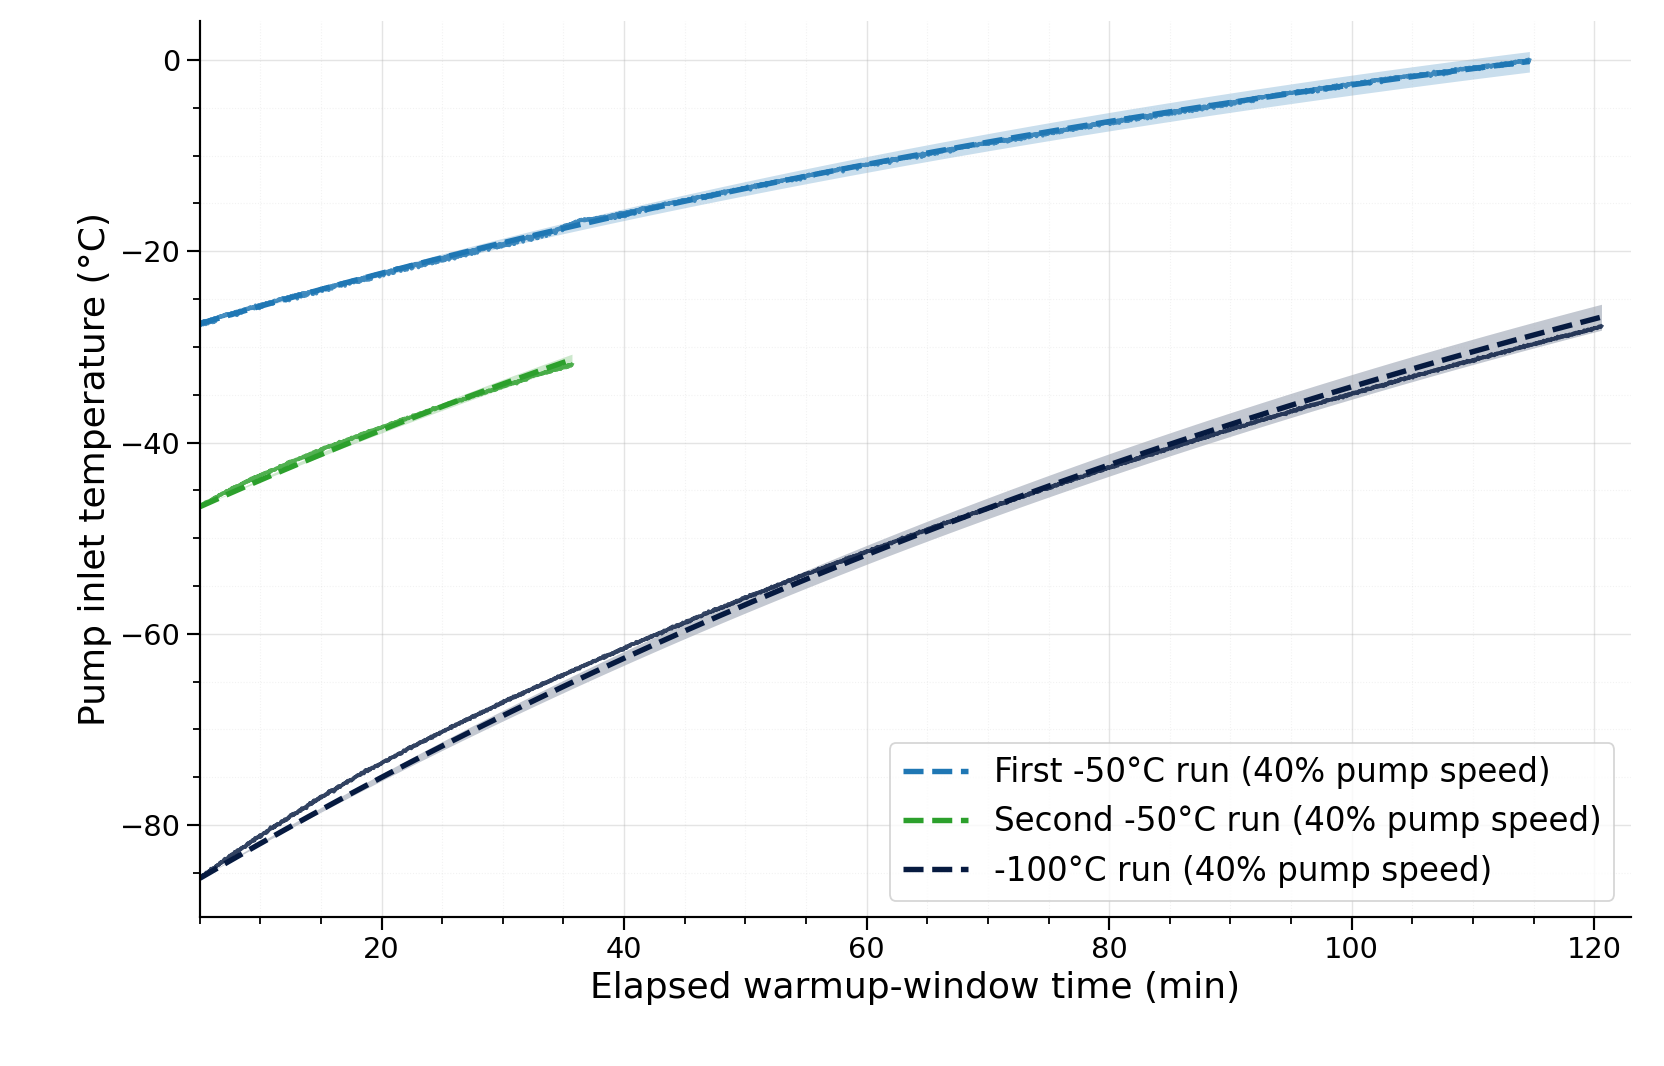

In [4]:
base_model = orca.default_system_model()
# Geometry values matched to the dissertation description. The HFE liquid mass
# is taken from the fill estimate, not from the geometric volume.
HFE_LOOP_TUBING_LENGTH_M = 5.5
HFE_LOOP_TUBING_OD_M = 3.0 / 8.0 * 0.0254
HFE_LOOP_TUBING_ID_M = 0.007747
HFE_LOOP_TUBING_WALL_M = 0.5 * (HFE_LOOP_TUBING_OD_M - HFE_LOOP_TUBING_ID_M)
HX_COIL_LENGTH_M = 6.1
HX_COIL_OD_M = 0.25 * 0.0254
HX_COIL_WALL_M = 0.049 * 0.0254
# Use stainless density rounded to 8.0 g/cm^3 for both 316-family and 304L tubing.
STAINLESS_316_DENSITY_KG_M3 = 8000.0
STAINLESS_304L_DENSITY_KG_M3 = 8000.0
TANK_STEEL_MASS_KG = 17.8
TANK_STEEL_MASS_SIGMA_KG = 0.2
PUMP_HEAD_DIAMETER_M = 0.085
PUMP_HEAD_DEPTH_M = 0.065
PUMP_HEAD_DIMENSION_SIGMA_M = 0.005  # 0.5 cm envelope uncertainty for the rough cylinder estimate
TUBING_MASS_REL_SIGMA = 0.05  # geometry/density envelope for tubing-derived steel masses

model = dataclass_replace(
    base_model,
    process_loop=orca.StraightTube(
        length_m=HFE_LOOP_TUBING_LENGTH_M,
        outer_diameter_m=HFE_LOOP_TUBING_OD_M,
        wall_thickness_m=HFE_LOOP_TUBING_WALL_M,
    ),
    heat_exchanger=orca.StraightTube(
        length_m=HX_COIL_LENGTH_M,
        outer_diameter_m=HX_COIL_OD_M,
        wall_thickness_m=HX_COIL_WALL_M,
    ),
)
ambient_c = float(model.ambient_temp_k - 273.15)
active_hfe_liquid_kg = ROOM_TEMPERATURE_HFE_MASS_KG
active_hfe_liquid_sigma_kg = ROOM_TEMPERATURE_HFE_MASS_SIGMA_KG
loop_tubing_mass_kg = model.process_loop.steel_volume_m3 * STAINLESS_316_DENSITY_KG_M3
hx_coil_mass_kg = model.heat_exchanger.steel_volume_m3 * STAINLESS_304L_DENSITY_KG_M3
loop_tubing_mass_sigma_kg = TUBING_MASS_REL_SIGMA * loop_tubing_mass_kg
hx_coil_mass_sigma_kg = TUBING_MASS_REL_SIGMA * hx_coil_mass_kg
pump_head_volume_m3 = np.pi * (0.5 * PUMP_HEAD_DIAMETER_M) ** 2 * PUMP_HEAD_DEPTH_M
pump_head_mass_kg = pump_head_volume_m3 * STAINLESS_316_DENSITY_KG_M3
pump_head_mass_sigma_kg = pump_head_mass_kg * np.sqrt(
    (2.0 * PUMP_HEAD_DIMENSION_SIGMA_M / PUMP_HEAD_DIAMETER_M) ** 2
    + (PUMP_HEAD_DIMENSION_SIGMA_M / PUMP_HEAD_DEPTH_M) ** 2
)
cold_hardware_steel_mass_kg = loop_tubing_mass_kg + hx_coil_mass_kg + TANK_STEEL_MASS_KG + pump_head_mass_kg
steel_mass_sigma_kg = float(np.sqrt(
    loop_tubing_mass_sigma_kg**2
    + hx_coil_mass_sigma_kg**2
    + TANK_STEEL_MASS_SIGMA_KG**2
    + pump_head_mass_sigma_kg**2
))
steel_heat_capacity_j_k = cold_hardware_steel_mass_kg * model.steel_cp_j_kgk
rho_room = orca.hfe_density_kg_m3(model.ambient_temp_k)

mass_model_summary = pd.DataFrame([
    {
        'component': 'cold-loop tubing',
        'basis': '316 SS tubing geometry',
        'mass_kg': loop_tubing_mass_kg,
        'mass_sigma_kg': loop_tubing_mass_sigma_kg,
    },
    {
        'component': 'LN2 heat-exchanger coil',
        'basis': '304L SS coil geometry',
        'mass_kg': hx_coil_mass_kg,
        'mass_sigma_kg': hx_coil_mass_sigma_kg,
    },
    {
        'component': 'tank shell',
        'basis': 'measured tank mass',
        'mass_kg': TANK_STEEL_MASS_KG,
        'mass_sigma_kg': TANK_STEEL_MASS_SIGMA_KG,
    },
    {
        'component': 'pump head',
        'basis': 'solid-cylinder estimate',
        'mass_kg': pump_head_mass_kg,
        'mass_sigma_kg': pump_head_mass_sigma_kg,
    },
    {
        'component': 'total steel in capacity model',
        'basis': 'loop tubing + HX coil + measured tank + pump head estimate',
        'mass_kg': cold_hardware_steel_mass_kg,
        'mass_sigma_kg': steel_mass_sigma_kg,
    },
    {
        'component': 'HFE inventory at room temperature',
        'basis': 'fill estimate',
        'mass_kg': active_hfe_liquid_kg,
        'mass_sigma_kg': active_hfe_liquid_sigma_kg,
    },
])
display(Markdown('### Cold hardware mass model'))
display(mass_model_summary.round({'mass_kg': 3, 'mass_sigma_kg': 3}))
display(Markdown(f'Steel heat capacity used in cooldown model: `{steel_heat_capacity_j_k:.0f} J/K`.'))


PUMP_INLET_TEMP_COL = 'TMI_C'
PUMP_INLET_TEMP_LABEL = 'Pump inlet temperature (°C)'
TYPE_T_LN2_C = -195.8
TYPE_T_ROOM_C = 20.2778
TYPE_T_U_LN2_C = 0.049
TYPE_T_U_ROOM_C = 0.058
WARMUP_FIT_START_MIN = 5.0
DISSERTATION_FIGSIZE = (12.8, 8.2)
DISSERTATION_LABEL_FONTSIZE = 20
DISSERTATION_TICK_FONTSIZE = 16
DISSERTATION_LEGEND_FONTSIZE = 18
DISSERTATION_TITLE_FONTSIZE = 20
DISSERTATION_ANNOTATION_FONTSIZE = 14
DISSERTATION_LINEWIDTH = 2.0
DISSERTATION_FIT_LINEWIDTH = 3.0
DISSERTATION_SINGLE_ADJUST = dict(left=0.12, right=0.98, top=0.98, bottom=0.14)
DISSERTATION_PANEL_ADJUST = dict(left=0.10, right=0.98, top=0.92, bottom=0.14, wspace=0.08)
DISSERTATION_COLORBAR_ADJUST = dict(left=0.12, right=0.86, top=0.98, bottom=0.14)

for key in HEAT_LEAK_RUN_KEYS:
    if PUMP_INLET_TEMP_COL not in runs[key]['data'].columns:
        raise RuntimeError(f"{PUMP_INLET_TEMP_COL} is missing from {runs[key]['config']['label']}.")


def _temperature_sigma_band(temp_c):
    temp = np.asarray(temp_c, dtype=float)
    denom = TYPE_T_ROOM_C - TYPE_T_LN2_C
    f_ln2 = (TYPE_T_ROOM_C - temp) / denom
    f_room = (temp - TYPE_T_LN2_C) / denom
    return np.sqrt((f_ln2 * TYPE_T_U_LN2_C) ** 2 + (f_room * TYPE_T_U_ROOM_C) ** 2)


def _warmup_temperature_curve_for_ua(fit, elapsed_s, ua_w_per_k):
    elapsed = np.asarray(elapsed_s, dtype=float)
    ua = max(float(ua_w_per_k), 1e-12)
    return fit.ambient_c - (fit.ambient_c - fit.initial_temp_c) * np.exp(
        -elapsed * ua / fit.capacity_j_per_k
    )


def _active_inventory_mass_kg(_log_key):
    return active_hfe_liquid_kg


def _slice_time(frame, start_s, end_s):
    work = frame[frame['time_s'].between(float(start_s), float(end_s))].copy().sort_values('time_s')
    return work.reset_index(drop=True)


def _phase_frame_from_step(log_key, step_id):
    row = runs[log_key]['step_windows'].loc[int(step_id)]
    return _slice_time(runs[log_key]['data'], row['start_s'], row['end_s'])


def _pump_speed_frame(frame, pump_pct):
    work = frame.copy().sort_values('time_s').reset_index(drop=True)
    pump_cmd = pd.to_numeric(work['pump_cmd_pct'], errors='coerce')
    mask = pump_cmd.round().eq(float(pump_pct))
    if not mask.any():
        raise RuntimeError(f'No samples matching the selected pump-speed command ({pump_pct:.0f}%) were found in the selected warmup frame.')
    return work.loc[mask].copy().reset_index(drop=True)


def _ln_open_segments(frame):
    valve_col = 'valve_state' if 'valve_state' in frame.columns else 'valve'
    work = frame.copy().sort_values('time_s').reset_index(drop=True)
    open_mask = pd.to_numeric(work[valve_col], errors='coerce').fillna(0.0).gt(0.5)
    if not open_mask.any():
        return pd.DataFrame(columns=['start_s', 'end_s', 'start_min', 'end_min', 'samples'])
    work['_ln_open'] = open_mask
    work['_group'] = work['_ln_open'].ne(work['_ln_open'].shift(fill_value=False)).cumsum()
    return (
        work[work['_ln_open']]
        .groupby('_group', as_index=False)
        .agg(
            start_s=('time_s', 'first'),
            end_s=('time_s', 'last'),
            start_min=('t_min', 'first'),
            end_min=('t_min', 'last'),
            samples=('time_s', 'size'),
        )
    )


def _first_time_at_or_below(frame, temperature_col, threshold_c):
    work = frame[frame[temperature_col].le(float(threshold_c))].copy().sort_values('time_s')
    if work.empty:
        raise RuntimeError(f'No samples at or below {threshold_c} C in the selected frame.')
    return float(work['time_s'].iloc[0])


def _warmup_from_coldest(frame, temperature_col=PUMP_INLET_TEMP_COL):
    work = frame.copy().sort_values('time_s').reset_index(drop=True)
    if work.empty:
        raise RuntimeError('Cannot create a warmup window from an empty frame.')
    start_pos = int(np.nanargmin(work[temperature_col].to_numpy(float)))
    return work.iloc[start_pos:].copy().reset_index(drop=True)


APR22_PHASE_STEP_IDS = {'P2': 6, 'P3': 7, 'P5': 13}
apr22_phases = {phase: _phase_frame_from_step('0422', step_id) for phase, step_id in APR22_PHASE_STEP_IDS.items()}
apr24_w1_step = runs['0424']['step_windows'].loc[11]

apr17_warmup_by_label = {label: (color, desc, start_s, end_s) for label, color, desc, start_s, end_s, _fit_start_min in APR17_WARMUP_DEFS}
apr17_w3_color, _apr17_w3_desc, apr17_w3_start_s, apr17_w3_end_s = apr17_warmup_by_label['W3']
apr17_w3_40pct = _pump_speed_frame(_slice_time(runs['0417']['data'], apr17_w3_start_s, apr17_w3_end_s), 40.0)

warmup_window_entries = [
    {
        'label': '0417 W3',
        'color': apr17_w3_color,
        'desc': 'Apr 17: W3, 40% pump speed',
        'legend': 'First -50°C run (40% pump speed)',
        'log_key': '0417',
        'frame': apr17_w3_40pct,
        'fit_start_min': WARMUP_FIT_START_MIN,
    },
    {
        'label': '0422 W3',
        'color': LOG_COLORS['0422'],
        'desc': 'Apr 22: P5 warmup, 40% pump speed',
        'legend': 'Second -50°C run (40% pump speed)',
        'log_key': '0422',
        'frame': _warmup_from_coldest(apr22_phases['P5']),
        'fit_start_min': WARMUP_FIT_START_MIN,
    },
    {
        'label': '0424 W1',
        'color': LOG_COLORS['0424'],
        'desc': 'Apr 24: 40% warmup after 172 min',
        'legend': '-100°C run (40% pump speed)',
        'log_key': '0424',
        'frame': _slice_time(runs['0424']['data'], apr24_w1_step['start_s'], apr24_w1_step['end_s']),
        'fit_start_min': WARMUP_FIT_START_MIN,
    },
]

warmup_fit_results = {}
heat_leak_rows = []
window_rows = []
for entry in warmup_window_entries:
    frame = entry['frame'].copy().sort_values('time_s').reset_index(drop=True)
    frame['elapsed_min'] = (frame['time_s'] - float(frame['time_s'].iloc[0])) / 60.0
    entry['frame'] = frame
    entry['active_hfe_liquid_kg'] = _active_inventory_mass_kg(entry['log_key'])

    fit = orca.fit_warmup_segment(
        frame,
        active_hfe_liquid_kg=entry['active_hfe_liquid_kg'],
        temperature_col=PUMP_INLET_TEMP_COL,
        time_col='time_s',
        pump_power_col='pump_input_power_w',
        fit_start_min=entry['fit_start_min'],
        min_samples=20,
        model=model,
        sigma_mass_kg=active_hfe_liquid_sigma_kg,
        steel_heat_capacity_j_k=steel_heat_capacity_j_k,
        sigma_steel_mass_kg=steel_mass_sigma_kg,
        temperature_sigma_c=_temperature_sigma_band,
    )
    entry['fit'] = fit
    warmup_fit_results[entry['label']] = entry

    fit_window_label = f"{entry['fit_start_min']:.1f}-end"
    window_rows.append({
        'segment': entry['label'],
        'description': entry['desc'],
        'start_min': float(frame['time_s'].iloc[0] / 60.0),
        'end_min': float(frame['time_s'].iloc[-1] / 60.0),
        'duration_min': float(frame['elapsed_min'].iloc[-1]),
        'fit_window_min': fit_window_label,
        'start_TMI_C': float(frame[PUMP_INLET_TEMP_COL].iloc[0]),
        'fit_start_TMI_C': float(fit.fit_temperature_C[0]),
        'end_TMI_C': float(frame[PUMP_INLET_TEMP_COL].iloc[-1]),
    })
    heat_leak_rows.append({
        'segment': entry['label'],
        'description': entry['desc'],
        'active_HFE_kg': entry['active_hfe_liquid_kg'],
        'fit_window_min': fit_window_label,
        'UA_W_per_K': fit.ua_w_per_k,
        'UA_sigma_W_per_K': fit.ua_sigma_w_per_k,
        'tau_min': fit.tau_s / 60.0,
        'r2': fit.r_squared,
        'rmse_C': fit.rmse_C,
        'Q_leak_at_-110C_W': fit.heat_leak_at_temperature_C(-110.0),
        'Q_leak_at_-100C_W': fit.heat_leak_at_temperature_C(-100.0),
        'Q_leak_at_-90C_W': fit.heat_leak_at_temperature_C(-90.0),
    })

warmup_windows = pd.DataFrame(window_rows).set_index('segment')
heat_leak_summary = pd.DataFrame(heat_leak_rows).set_index('segment')
warmup_fit_table = pd.DataFrame([
    {
        'Window': entry['label'],
        'Description': entry['desc'],
        'Fit window (min)': f"{entry['fit_start_min']:.1f}-end",
        'UA (W/K)': f"{entry['fit'].ua_w_per_k:.3f} +/- {entry['fit'].ua_sigma_w_per_k:.3f}",
        'tau (min)': f"{entry['fit'].tau_s / 60.0:.1f} +/- {entry['fit'].tau_s / 60.0 * entry['fit'].ua_sigma_w_per_k / entry['fit'].ua_w_per_k:.1f}",
        'Q leak @ -110°C (W)': f"{entry['fit'].heat_leak_at_temperature_C(-110.0):.1f} +/- {entry['fit'].heat_leak_sigma_at_temperature_C(-110.0):.1f}",
        'R2': f"{entry['fit'].r_squared:.3f}",
        'RMSE (°C)': f"{entry['fit'].rmse_C:.2f}",
    }
    for entry in warmup_window_entries
]).set_index('Window')

fig_warmup, ax = plt.subplots(figsize=DISSERTATION_FIGSIZE, constrained_layout=False)

all_temps = []
max_elapsed_min = WARMUP_FIT_START_MIN
for entry in warmup_window_entries:
    frame = entry['frame']
    fit = entry['fit']
    color = entry['color']
    raw_t = frame['elapsed_min'].to_numpy(float)
    raw_T = frame[PUMP_INLET_TEMP_COL].to_numpy(float)
    sigma_raw = _temperature_sigma_band(raw_T)
    visible = raw_t >= WARMUP_FIT_START_MIN
    all_temps.extend(raw_T[visible & np.isfinite(raw_T)])
    max_elapsed_min = max(max_elapsed_min, float(raw_t[-1]))

    fit_time_min = fit.fit_start_min + fit.fit_elapsed_s / 60.0
    curve_elapsed_min = np.linspace(fit.fit_start_min, fit.fit_end_min, 300)
    curve_elapsed_s = (curve_elapsed_min - fit.fit_start_min) * 60.0
    curve_temp_c = fit.predict_temperature_C(curve_elapsed_s)
    ua_sigma = float(fit.ua_sigma_w_per_k)
    if np.isfinite(ua_sigma) and ua_sigma > 0.0:
        curve_low_ua = _warmup_temperature_curve_for_ua(fit, curve_elapsed_s, fit.ua_w_per_k - ua_sigma)
        curve_high_ua = _warmup_temperature_curve_for_ua(fit, curve_elapsed_s, fit.ua_w_per_k + ua_sigma)
        curve_band_low = np.minimum(curve_low_ua, curve_high_ua)
        curve_band_high = np.maximum(curve_low_ua, curve_high_ua)
    else:
        curve_band_low = curve_temp_c
        curve_band_high = curve_temp_c

    ax.fill_between(raw_t, raw_T - sigma_raw, raw_T + sigma_raw, color=color, alpha=0.14, linewidth=0)
    ax.plot(raw_t, raw_T, color=color, alpha=0.34, lw=DISSERTATION_LINEWIDTH)
    ax.plot(fit_time_min, fit.fit_temperature_C, color=color, alpha=0.72, lw=DISSERTATION_LINEWIDTH)
    ax.fill_between(curve_elapsed_min, curve_band_low, curve_band_high, color=color, alpha=0.24, linewidth=0)
    ax.plot(curve_elapsed_min, curve_temp_c, color=color, lw=DISSERTATION_FIT_LINEWIDTH, linestyle='--', label=entry['legend'])

ax.set_xlim(left=WARMUP_FIT_START_MIN, right=max_elapsed_min * 1.02)
if all_temps:
    ax.set_ylim(min(all_temps) - 4.0, max(all_temps) + 4.0)
ax.set_xlabel('Elapsed warmup-window time (min)', fontsize=DISSERTATION_LABEL_FONTSIZE)
ax.set_ylabel('Pump inlet temperature (°C)', fontsize=DISSERTATION_LABEL_FONTSIZE)
ax.tick_params(axis='both', which='major', labelsize=DISSERTATION_TICK_FONTSIZE, length=7, width=1.2)
ax.tick_params(axis='both', which='minor', length=4, width=1.0)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
ax.legend(loc='best', fontsize=DISSERTATION_LEGEND_FONTSIZE)
_apply_fine_grid(ax)
fig_warmup.subplots_adjust(**DISSERTATION_SINGLE_ADJUST)
plt.show()


In [5]:
display(warmup_fit_table)
display(warmup_windows.round(2))


,Description,Fit window (min),UA (W/K),tau (min),Q leak @ -110°C (W),R2,RMSE (°C)
Window,,,,,,,
0417 W3,"Apr 17: W3, 40% pump speed",5.0-end,2.155 +/- 0.134,127.0 +/- 7.9,279.8 +/- 17.4,1.000,0.13
0422 W3,"Apr 22: P5 warmup, 40% pump speed",5.0-end,2.324 +/- 0.097,116.6 +/- 4.8,301.8 +/- 12.5,0.993,0.36
0424 W1,Apr 24: 40% warmup after 172 min,5.0-end,1.897 +/- 0.068,142.1 +/- 5.1,246.3 +/- 8.8,0.997,0.87


,description,start_min,end_min,duration_min,fit_window_min,start_TMI_C,fit_start_TMI_C,end_TMI_C
segment,,,,,,,,
0417 W3,"Apr 17: W3, 40% pump speed",13047.84,13162.50,114.66,5.0-end,-29.46,-27.57,0.01
0422 W3,"Apr 22: P5 warmup, 40% pump speed",384.99,420.69,35.70,5.0-end,-51.65,-46.70,-31.84
0424 W1,Apr 24: 40% warmup after 172 min,172.78,293.39,120.60,5.0-end,-91.25,-85.55,-27.83


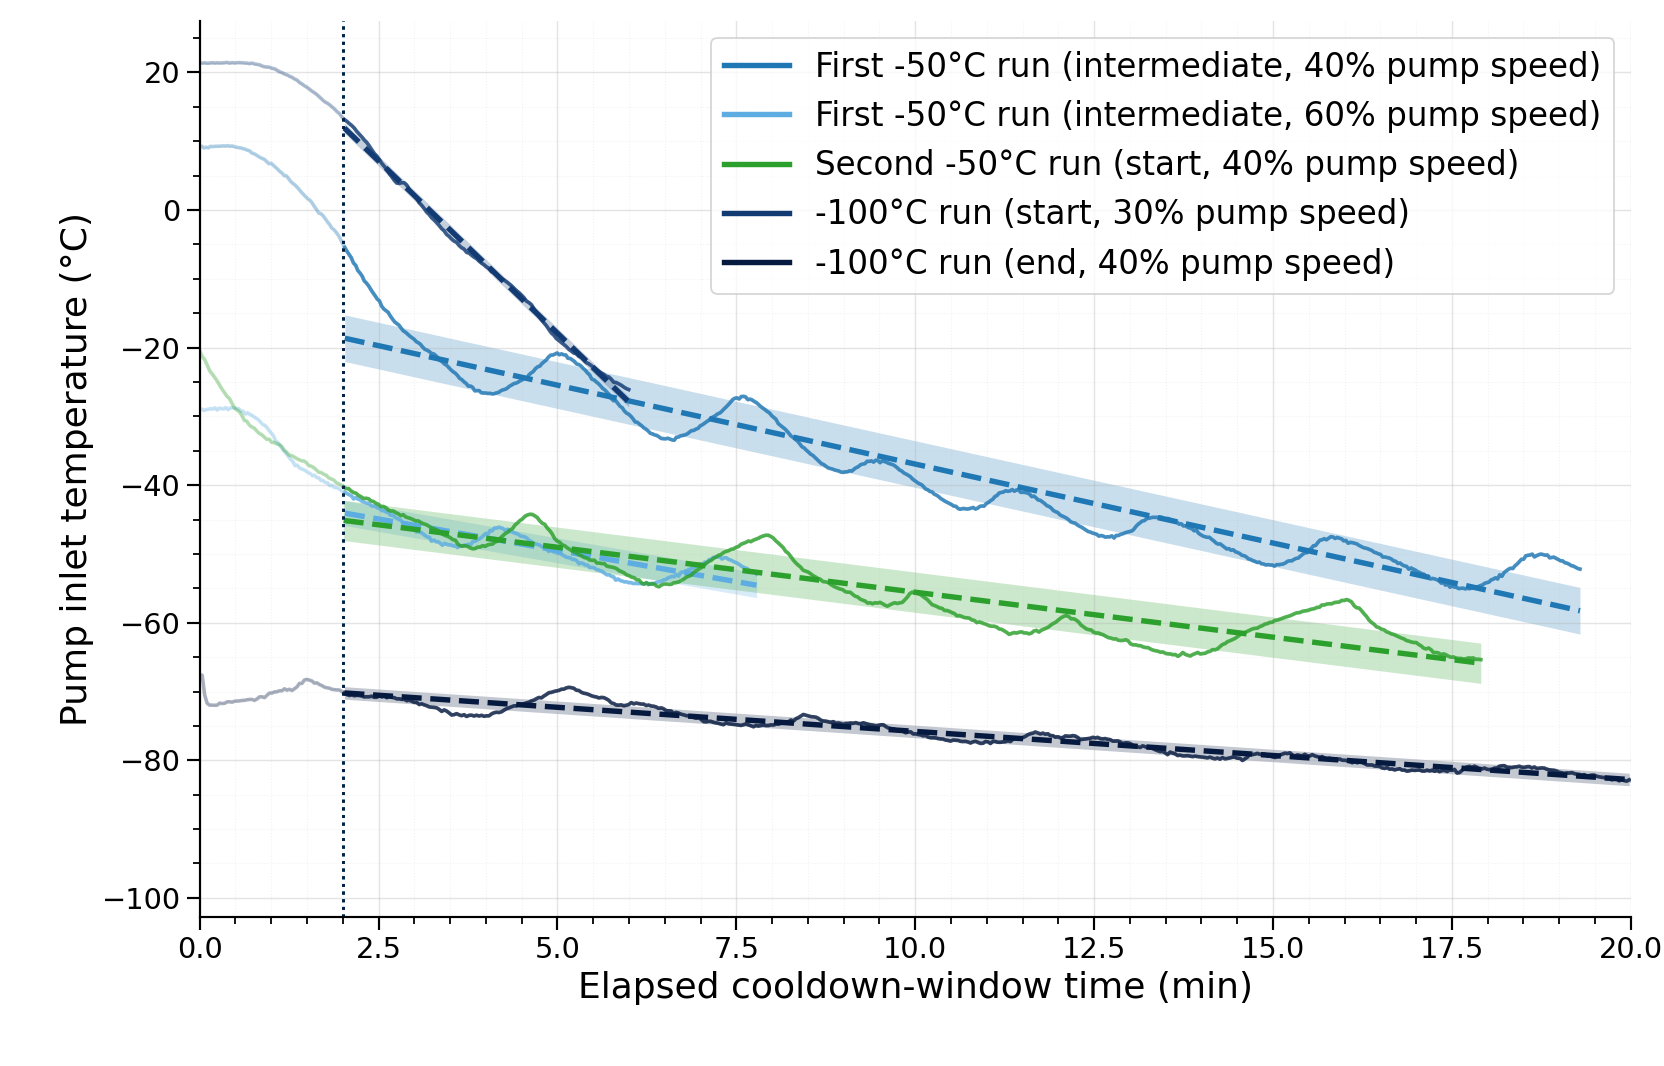

In [6]:
DERIVATIVE_WINDOW_S = 240.0
APR17_DERIVATIVE_WINDOW_S = 180.0
COOLDOWN_FIT_START_MIN = 2.0
COOLDOWN_XMAX_MIN = 20.0
APR24_FIRST_LN_OPEN_DURATION_MIN = 6.0
TARGET_COLD_TEMP_C = -110.0
HFE_WALL_LIMIT_C = -121.0
DISSERTATION_LABEL_FONTSIZE = 20
DISSERTATION_TICK_FONTSIZE = 16
DISSERTATION_LEGEND_FONTSIZE = 18
DISSERTATION_LINEWIDTH = 2.0
DISSERTATION_FIT_LINEWIDTH = 3.0


def _effective_capacity_j_per_k(temperature_c, *, active_hfe_liquid_kg):
    return np.asarray([
        active_hfe_liquid_kg * (orca.hfe_density_kg_m3(float(temp_c) + 273.15) / rho_room)
        * orca.hfe_specific_heat_j_kgk(float(temp_c) + 273.15) + steel_heat_capacity_j_k
        for temp_c in temperature_c
    ])


def _effective_capacity_sigma_j_per_k(temperature_c, *, active_hfe_liquid_sigma_kg, steel_mass_sigma_kg=0.0):
    return np.asarray([
        np.hypot(
            active_hfe_liquid_sigma_kg * (orca.hfe_density_kg_m3(float(temp_c) + 273.15) / rho_room)
            * orca.hfe_specific_heat_j_kgk(float(temp_c) + 273.15),
            steel_mass_sigma_kg * model.steel_cp_j_kgk,
        )
        for temp_c in temperature_c
    ])


apr22_p2_open = _ln_open_segments(apr22_phases['P2'])
if apr22_p2_open.empty:
    raise RuntimeError('Could not find LN valve-open samples in the requested Apr 22 P2 phase.')

apr22_cd2_start_s = _first_time_at_or_below(apr22_phases['P2'], PUMP_INLET_TEMP_COL, -20.0)
apr22_cd2_end_s = float(apr22_phases['P2'].loc[apr22_phases['P2'][PUMP_INLET_TEMP_COL].idxmin(), 'time_s'])

apr24_open = _ln_open_segments(runs['0424']['run'])
if apr24_open.empty:
    raise RuntimeError('Could not find LN valve-open samples in the Apr 24 run.')

apr24_cd1_start_s = float(apr24_open['start_s'].iloc[0])
apr24_cd1_end_s = min(float(apr24_open['end_s'].iloc[0]), apr24_cd1_start_s + APR24_FIRST_LN_OPEN_DURATION_MIN * 60.0)
apr24_cd2_start_s = float(runs['0424']['bypass_marker_min'] * 60.0)
apr24_cd2_end_s = 140.0 * 60.0

apr17_cooldown_legends = {
    'CD2': 'First -50°C run (intermediate, 40% pump speed)',
    'CD3': 'First -50°C run (intermediate, 60% pump speed)',
}
apr17_cooldown_colors = {
    'CD2': LOG_COLORS['0417'],
    'CD3': RUN_ACCENT_COLORS['0417_light'],
}


cooldown_window_entries = []
for cooldown_label, color, description, start_s, end_s, fit_start_min in APR17_COOLDOWN_DEFS:
    cooldown_window_entries.append({
        'label': f'0417 {cooldown_label}',
        'color': apr17_cooldown_colors[cooldown_label],
        'desc': f'Apr 17: {description}',
        'legend': apr17_cooldown_legends[cooldown_label],
        'log_key': '0417',
        'frame': _slice_time(runs['0417']['data'], start_s, end_s),
        'fit_start_min': COOLDOWN_FIT_START_MIN,
        'warmup_label': '0417 W3',
        'rolling_window_s': APR17_DERIVATIVE_WINDOW_S,
    })

cooldown_window_entries.extend([
    {
        'label': '0422 CD2',
        'color': LOG_COLORS['0422'],
        'desc': 'Apr 22: P2, -20 C to TMI minimum',
        'legend': 'Second -50°C run (start, 40% pump speed)',
        'log_key': '0422',
        'frame': _slice_time(runs['0422']['data'], apr22_cd2_start_s, apr22_cd2_end_s),
        'fit_start_min': COOLDOWN_FIT_START_MIN,
        'warmup_label': '0422 W3',
        'rolling_window_s': DERIVATIVE_WINDOW_S,
    },
    {
        'label': '0424 CD1',
        'color': RUN_ACCENT_COLORS['0424_light'],
        'desc': 'Apr 24: first 6 min of LN valve-open period',
        'legend': '-100°C run (start, 30% pump speed)',
        'log_key': '0424',
        'frame': _slice_time(runs['0424']['data'], apr24_cd1_start_s, apr24_cd1_end_s),
        'fit_start_min': COOLDOWN_FIT_START_MIN,
        'warmup_label': '0424 W1',
        'rolling_window_s': DERIVATIVE_WINDOW_S,
    },
    {
        'label': '0424 CD2',
        'color': LOG_COLORS['0424'],
        'desc': 'Apr 24: bypass closed to 140 min',
        'legend': '-100°C run (end, 40% pump speed)',
        'log_key': '0424',
        'frame': _slice_time(runs['0424']['data'], apr24_cd2_start_s, apr24_cd2_end_s),
        'fit_start_min': COOLDOWN_FIT_START_MIN,
        'fit_end_min': 20.0,
        'warmup_label': '0424 W1',
        'rolling_window_s': DERIVATIVE_WINDOW_S,
    },
])

cooldown_window_rows = []
for entry in cooldown_window_entries:
    frame = entry['frame'].copy().sort_values('time_s').reset_index(drop=True)
    frame['elapsed_min'] = (frame['time_s'] - float(frame['time_s'].iloc[0])) / 60.0
    entry['frame'] = frame
    cooldown_window_rows.append({
        'segment': entry['label'],
        'description': entry['desc'],
        'start_min': float(frame['time_s'].iloc[0] / 60.0),
        'end_min': float(frame['time_s'].iloc[-1] / 60.0),
        'duration_min': float(frame['elapsed_min'].iloc[-1]),
        'fit_start_min': entry['fit_start_min'],
        'fit_end_min': entry.get('fit_end_min', np.nan),
        'start_TMI_C': float(frame[PUMP_INLET_TEMP_COL].iloc[0]),
        'end_TMI_C': float(frame[PUMP_INLET_TEMP_COL].iloc[-1]),
        'leak_calibration': entry['warmup_label'],
    })

cooldown_windows = pd.DataFrame(cooldown_window_rows).set_index('segment')

fig_cooling, ax_temp = plt.subplots(figsize=DISSERTATION_FIGSIZE, constrained_layout=False)

cooldown_summary_rows = []
cooldown_fit_rows = []
for entry in cooldown_window_entries:
    frame = entry['frame']
    fit = warmup_fit_results[entry['warmup_label']]['fit']
    ua_leak_w_per_k = float(fit.ua_w_per_k)
    active_mass_kg = _active_inventory_mass_kg(entry['log_key'])
    color = entry['color']

    T_arr = frame[PUMP_INLET_TEMP_COL].to_numpy(float)
    t_s = frame['time_s'].to_numpy(float)
    t_arr = frame['elapsed_min'].to_numpy(float)
    sigma_full = _temperature_sigma_band(T_arr)
    ax_temp.fill_between(t_arr, T_arr - sigma_full, T_arr + sigma_full, color=color, alpha=0.14, linewidth=0)
    ax_temp.plot(t_arr, T_arr, color=color, lw=DISSERTATION_LINEWIDTH, alpha=0.34)

    valid_temp_mask = np.isfinite(t_s) & np.isfinite(t_arr) & np.isfinite(T_arr)
    fit_mask = valid_temp_mask & (t_arr >= float(entry['fit_start_min']))
    fit_end_min = entry.get('fit_end_min')
    if fit_end_min is not None:
        fit_mask &= t_arr <= float(fit_end_min)
    t_s_fit = t_s[fit_mask]
    T_arr_fit = T_arr[fit_mask]
    t_arr_fit = t_arr[fit_mask]
    if len(T_arr_fit) < 3:
        t_s_fit, T_arr_fit, t_arr_fit = t_s[valid_temp_mask], T_arr[valid_temp_mask], t_arr[valid_temp_mask]
    t_centered = t_s_fit - float(t_s_fit.mean())
    denom = float(np.dot(t_centered, t_centered))
    slope_C_per_s = float(np.dot(t_centered, T_arr_fit) / denom)
    intercept = float(T_arr_fit.mean() - slope_C_per_s * t_s_fit.mean())
    T_fit = slope_C_per_s * t_s_fit + intercept
    residual_std = float(np.std(T_arr_fit - T_fit, ddof=2)) if len(T_arr_fit) > 2 else float('nan')
    sigma_slope_C_per_s = residual_std / float(np.sqrt(denom)) if np.isfinite(residual_std) else float('nan')
    sigma_fit = _temperature_sigma_band(T_arr_fit)

    ax_temp.fill_between(t_arr_fit, T_arr_fit - sigma_fit, T_arr_fit + sigma_fit, color=color, alpha=0.20, linewidth=0)
    ax_temp.plot(t_arr_fit, T_arr_fit, color=color, lw=DISSERTATION_LINEWIDTH, alpha=0.72)
    if entry['fit_start_min'] > 0.0:
        ax_temp.axvline(entry['fit_start_min'], color=color, lw=1.6, linestyle=':', alpha=0.90)
    if np.isfinite(residual_std):
        ax_temp.fill_between(t_arr_fit, T_fit - residual_std, T_fit + residual_std, color=color, alpha=0.24, linewidth=0)
    ax_temp.plot(t_arr_fit, T_fit, color=color, lw=DISSERTATION_FIT_LINEWIDTH, linestyle='--')

    capacity_target = float(_effective_capacity_j_per_k([TARGET_COLD_TEMP_C], active_hfe_liquid_kg=active_mass_kg)[0])
    capacity_target_sigma = float(_effective_capacity_sigma_j_per_k(
        [TARGET_COLD_TEMP_C],
        active_hfe_liquid_sigma_kg=active_hfe_liquid_sigma_kg,
        steel_mass_sigma_kg=steel_mass_sigma_kg,
    )[0])
    q_net_target = capacity_target * abs(slope_C_per_s)
    q_net_target_sigma = np.hypot(capacity_target * sigma_slope_C_per_s, abs(slope_C_per_s) * capacity_target_sigma)
    q_leak_target = ua_leak_w_per_k * max(ambient_c - TARGET_COLD_TEMP_C, 0.0)
    q_leak_target_sigma = float(fit.ua_sigma_w_per_k * max(ambient_c - TARGET_COLD_TEMP_C, 0.0))
    q_hx_target = q_net_target + q_leak_target
    sigma_q_hx_target = float(np.hypot(q_net_target_sigma, q_leak_target_sigma))

    T_avg_fit = float(np.nanmean(T_arr_fit))
    capacity_avg = float(np.nanmean(_effective_capacity_j_per_k(T_arr_fit, active_hfe_liquid_kg=active_mass_kg)))
    capacity_avg_sigma = float(np.nanmean(_effective_capacity_sigma_j_per_k(
        T_arr_fit,
        active_hfe_liquid_sigma_kg=active_hfe_liquid_sigma_kg,
        steel_mass_sigma_kg=steel_mass_sigma_kg,
    )))
    q_net_avg = capacity_avg * abs(slope_C_per_s)
    q_net_avg_sigma = np.hypot(capacity_avg * sigma_slope_C_per_s, abs(slope_C_per_s) * capacity_avg_sigma)
    q_leak_avg = ua_leak_w_per_k * max(ambient_c - T_avg_fit, 0.0)
    q_leak_avg_sigma = float(fit.ua_sigma_w_per_k * max(ambient_c - T_avg_fit, 0.0))
    q_hx_avg = q_net_avg + q_leak_avg
    q_hx_avg_sigma = float(np.hypot(q_net_avg_sigma, q_leak_avg_sigma))
    hx_delta_t = max(T_avg_fit - HFE_WALL_LIMIT_C, 1.0)
    ua_hx = q_hx_avg / hx_delta_t
    sigma_ua_hx = q_hx_avg_sigma / hx_delta_t

    rate = orca.rolling_slope(t_s, T_arr, window_s=entry['rolling_window_s'], min_pts=11)
    capacity = _effective_capacity_j_per_k(T_arr, active_hfe_liquid_kg=active_mass_kg)
    q_inventory = -capacity * rate
    q_leak = ua_leak_w_per_k * np.clip(ambient_c - T_arr, 0.0, None)
    pump = pd.to_numeric(frame['pump_input_power_w'], errors='coerce').clip(lower=0.0).to_numpy(float)
    q_hx = q_inventory + q_leak
    q_hx_plus_pump = q_hx + pump
    cooling_mask = np.isfinite(rate) & (rate < 0.0) & (t_arr >= float(entry['fit_start_min']))

    slope_C_per_min = slope_C_per_s * 60.0
    sigma_slope_C_per_min = sigma_slope_C_per_s * 60.0
    fit_window_label = (
        f"{entry['fit_start_min']:.1f}-{entry['fit_end_min']:.1f}"
        if entry.get('fit_end_min') is not None else f"{entry['fit_start_min']:.1f}-end"
    )
    cooldown_fit_rows.append({
        'Window': entry['label'],
        'Description': entry['desc'],
        'Fit window (min)': fit_window_label,
        'dT/dt (°C/min)': f"{slope_C_per_min:.3f} +/- {sigma_slope_C_per_min:.3f}",
        'HX UA to -121°C (W/K)': f"{ua_hx:.3f} +/- {sigma_ua_hx:.3f}",
        f'Q_HX @ {TARGET_COLD_TEMP_C:.0f}°C (W)': f"{q_hx_target:.1f} +/- {sigma_q_hx_target:.1f}",
    })

    if cooling_mask.any():
        cooldown_summary_rows.append({
            'segment': entry['label'],
            'leak_calibration': entry['warmup_label'],
            'cooling_samples': int(cooling_mask.sum()),
            'median_TMI_C': float(np.nanmedian(T_arr[cooling_mask])),
            'cooldown_rate_C_per_min': float(-np.nanmedian(rate[cooling_mask]) * 60.0),
            'median_inventory_W': float(np.nanmedian(q_inventory[cooling_mask])),
            'median_leak_W': float(np.nanmedian(q_leak[cooling_mask])),
            'median_HX_W': float(np.nanmedian(q_hx[cooling_mask])),
            'median_HX_plus_pump_W': float(np.nanmedian(q_hx_plus_pump[cooling_mask])),
            'median_pump_input_W': float(np.nanmedian(pump[cooling_mask])),
        })

cooldown_fit_table = pd.DataFrame(cooldown_fit_rows).set_index('Window')
cooldown_summary = pd.DataFrame(cooldown_summary_rows).set_index('segment')
cooldown_uncertainty_summary = pd.DataFrame({
    'temperature_C': [-110.0, -70.0, -50.0, 20.2778],
})
cooldown_uncertainty_summary['Type_T_calibration_u_C'] = _temperature_sigma_band(
    cooldown_uncertainty_summary['temperature_C'].to_numpy(float)
)

ax_temp.set_xlabel('Elapsed cooldown-window time (min)', fontsize=DISSERTATION_LABEL_FONTSIZE)
ax_temp.set_ylabel('Pump inlet temperature (°C)', fontsize=DISSERTATION_LABEL_FONTSIZE)
ax_temp.set_xlim(0.0, COOLDOWN_XMAX_MIN)
ax_temp.tick_params(axis='both', which='major', labelsize=DISSERTATION_TICK_FONTSIZE, length=7, width=1.2)
ax_temp.tick_params(axis='both', which='minor', length=4, width=1.0)
for spine in ax_temp.spines.values():
    spine.set_linewidth(1.2)
seg_handles = [
    Line2D([0], [0], color=entry['color'], lw=DISSERTATION_FIT_LINEWIDTH, label=entry['legend'])
    for entry in cooldown_window_entries
    if entry.get('legend')
]
ax_temp.legend(handles=seg_handles, loc='best', fontsize=DISSERTATION_LEGEND_FONTSIZE)
_apply_fine_grid(ax_temp)
fig_cooling.subplots_adjust(**DISSERTATION_SINGLE_ADJUST)
plt.show()


In [7]:
def _style_large_table(frame):
    return (
        frame.style
        .set_table_styles([
            {'selector': 'th', 'props': [('font-size', '14pt'), ('font-weight', 'bold'), ('text-align', 'left')]},
            {'selector': 'td', 'props': [('font-size', '14pt'), ('text-align', 'left')]},
            {'selector': 'caption', 'props': [('font-size', '15pt'), ('font-weight', 'bold'), ('caption-side', 'top')]},
        ])
        .set_properties(**{'font-size': '14pt', 'text-align': 'left'})
    )

cooldown_fit_table_display = _style_large_table(cooldown_fit_table)
display(Markdown('### Cooldown fit table'))
display(cooldown_fit_table_display)

display(Markdown('### Cooldown window definitions'))
display(_style_large_table(cooldown_windows.round(2)))

display(Markdown('### Cooling power summary'))
display(_style_large_table(cooldown_summary.round(2)))

display(Markdown(
    'Temperature bands use the Type-T calibration-anchor uncertainty from the dissertation thermocouple calibration section. '
    'Readout noise and short-term scatter are not folded into this calibration band; they are represented separately by the fit residual bands and window statistics.'
))
display(cooldown_uncertainty_summary.round(4))


### Cooldown fit table

,Description,Fit window (min),dT/dt (°C/min),HX UA to -121°C (W/K),Q_HX @ -110°C (W)
Window,,,,,
0417 CD2,Apr 17: 40% pump speed,2.0-end,-2.295 +/- 0.028,9.057 +/- 0.233,880.5 +/- 23.9
0417 CD3,Apr 17: 60% pump speed,2.0-end,-1.821 +/- 0.078,8.935 +/- 0.365,756.5 +/- 29.2
0422 CD2,"Apr 22: P2, -20 C to TMI minimum",2.0-end,-1.307 +/- 0.030,8.046 +/- 0.213,643.8 +/- 16.9
0424 CD1,Apr 24: first 6 min of LN valve-open period,2.0-end,-10.016 +/- 0.060,24.753 +/- 0.641,2867.8 +/- 66.0
0424 CD2,Apr 24: bypass closed to 140 min,2.0-20.0,-0.701 +/- 0.008,8.304 +/- 0.185,429.7 +/- 10.0


### Cooldown window definitions

,description,start_min,end_min,duration_min,fit_start_min,fit_end_min,start_TMI_C,end_TMI_C,leak_calibration
segment,,,,,,,,,
0417 CD2,Apr 17: 40% pump speed,12964.030000,12983.320000,19.290000,2.000000,nan,9.230000,-52.200000,0417 W3
0417 CD3,Apr 17: 60% pump speed,13007.920000,13015.710000,7.780000,2.000000,nan,-28.950000,-52.910000,0417 W3
0422 CD2,"Apr 22: P2, -20 C to TMI minimum",303.140000,321.040000,17.900000,2.000000,nan,-20.460000,-65.360000,0422 W3
0424 CD1,Apr 24: first 6 min of LN valve-open period,21.530000,27.520000,6.000000,2.000000,nan,21.420000,-26.100000,0424 W1
0424 CD2,Apr 24: bypass closed to 140 min,57.960000,139.970000,82.010000,2.000000,20.000000,-67.520000,-96.520000,0424 W1


### Cooling power summary

,leak_calibration,cooling_samples,median_TMI_C,cooldown_rate_C_per_min,median_inventory_W,median_leak_W,median_HX_W,median_HX_plus_pump_W,median_pump_input_W
segment,,,,,,,,,
0417 CD2,0417 W3,519,-38.380000,2.130000,577.020000,125.460000,713.840000,781.480000,68.000000
0417 CD3,0417 W3,146,-48.460000,2.470000,665.210000,147.170000,816.880000,893.100000,77.000000
0422 CD2,0422 W3,279,-57.820000,2.390000,644.260000,180.530000,801.220000,870.220000,70.000000
0424 CD1,0424 W1,115,-8.270000,9.690000,2656.480000,53.340000,2711.660000,2774.660000,63.000000
0424 CD2,0424 W1,2048,-87.820000,0.330000,87.470000,204.240000,297.150000,366.950000,69.000000


Temperature bands use the Type-T calibration-anchor uncertainty from the dissertation thermocouple calibration section. Readout noise and short-term scatter are not folded into this calibration band; they are represented separately by the fit residual bands and window statistics.

,temperature_C,Type_T_calibration_u_C
0,-110.0000,0.0375
1,-70.0000,0.0395
2,-50.0000,0.0423
3,20.2778,0.0580


## Pressures

Bypass labels in these pressure plots refer to the HFE bypass path, not the LN valve. The April 17 run is treated as bypass open for the complete run. Open-bypass samples from April 22 and April 24 are excluded from the pressure plots and summaries, so those two runs are shown only in the bypass-closed state. April 22 samples below `-66°C` are excluded only from the pump pressure-rise ΔP plot; the pump-inlet and tank-pressure plots keep those colder samples.

The pressure-vs-temperature plots use only the nominal 40% pump-speed samples. Raw markers show all selected readings; the solid curve is a centered rolling mean in temperature using a `±3°C` window. The shaded band is a 1σ band on that rolling mean. It is an uncertainty band on the rolling mean, not a band intended to contain the full scatter of raw readings. It combines the pressure-sensor specification/resolution from dissertation Table 5.12 (`±0.03 bar`, treated as a rectangular Type-B contribution), the Arduino ADC and serial readout quantisation noise reduced as independent noise in each averaging window, the remaining rolling-window statistical standard error after removing that readout variance, and the Type-T temperature-calibration uncertainty from Eq. 5.67 propagated through the local pressure-temperature slope. Rechecking the components gives typical 1σ bands of about `0.025 bar` for pump ΔP and `0.017-0.018 bar` for the absolute pressure channels; these are smaller than the raw point spread because they are uncertainties on the rolling mean, not local scatter envelopes.

A separate pressure-vs-pump-speed plot uses narrow `TMI_C` temperature bands where several pump speeds were available: April 22 P4 at about `-50 ± 2°C`, and April 24 during the late speed-increase sequence from about `160 min` to the end of the 60% pump-speed step at about `-97 ± 2°C`. It shows pump pressure rise ΔP against pump speed, uses the same run colors as the other notebook plots, and fits the per-speed means with a weighted linear model. Before fitting, transition samples whose measured speed feedback is outside the discrete command-speed group are rejected, and remaining pressure spikes are removed with a robust per-speed outlier cut. The continuous shaded band is the ±1σ uncertainty on that fitted line, with the fit covariance inflated when residuals are larger than the per-speed mean uncertainties. The wider vertical bands show the raw ±1σ spread at each pump speed after outlier rejection.

A second pressure-temperature-speed scatter uses all available bypass-closed pumping samples from the April 22 and April 24 recirculations, with `TMI_C` on the temperature axis and pump command (%) encoded by color.

Run color carries the named recirculation run, and the legend states the bypass state used for each run. Pump inlet and tank pressures are shown in gauge pressure (`barg`); pressure differences are shown in `bar`.


In [8]:
PRESSURE_SENSOR_SPEC_HALF_WIDTH_BAR = 0.03  # dissertation Table 5.12 pressure-sensor specification/resolution
PRESSURE_SENSOR_SIGMA_BAR = PRESSURE_SENSOR_SPEC_HALF_WIDTH_BAR / np.sqrt(3.0)
PRESSURE_ADC_REF_V = 5.0
PRESSURE_ADC_COUNTS = 1023.0
PRESSURE_FSO_V = 5.013
PRESSURE_AFTER_ZERO_V = 0.029
PRESSURE_FSO_BAR = 10.0
PRESSURE_PSI_PER_BAR = 14.5037738
PRESSURE_PSI_PRINT_RESOLUTION = 0.001
PRESSURE_ADC_LSB_V = PRESSURE_ADC_REF_V / PRESSURE_ADC_COUNTS
PRESSURE_PSI_PRINT_SIGMA_BAR = (PRESSURE_PSI_PRINT_RESOLUTION / PRESSURE_PSI_PER_BAR) / np.sqrt(12.0)
PRESSURE_BEFORE_TANK_READOUT_SIGMA_BAR = np.sqrt(
    ((PRESSURE_ADC_LSB_V * PRESSURE_FSO_BAR / PRESSURE_FSO_V) / np.sqrt(12.0)) ** 2
    + PRESSURE_PSI_PRINT_SIGMA_BAR ** 2
)
PRESSURE_AFTER_READOUT_SIGMA_BAR = np.sqrt(
    ((PRESSURE_ADC_LSB_V * PRESSURE_FSO_BAR / (PRESSURE_FSO_V - PRESSURE_AFTER_ZERO_V)) / np.sqrt(12.0)) ** 2
    + PRESSURE_PSI_PRINT_SIGMA_BAR ** 2
)
PRESSURE_TEMPERATURE_ROLLING_HALF_WIDTH_C = 3.0
PRESSURE_TEMPERATURE_ROLLING_MIN_SAMPLES = 5
PRESSURE_TEMPERATURE_PUMP_CMD_PCT = 40.0
PRESSURE_TEMPERATURE_PUMP_CMD_TOL_PCT = 0.5
PRESSURE_SPEED_MIN_SAMPLES = 5
PRESSURE_SPEED_TEMPERATURE_COL = 'TMI_C'
PRESSURE_SPEED_TEMPERATURE_LABEL = 'Pump inlet temperature (°C)'
PRESSURE_SPEED_RPM_TOLERANCE = 15.0
PRESSURE_SPEED_OUTLIER_MAD_Z_LIMIT = 3.0
PRESSURE_SPEED_OUTLIER_MIN_TOLERANCE_BAR = 0.08
PRESSURE_SPEED_OUTLIER_METRICS = ('delta_p_bar_recomputed', 'pump_inlet_barg')
PRESSURE_BAND_ALPHA = 0.28
PRESSURE_BAND_EDGE_ALPHA = 0.70
PRESSURE_BAND_EDGE_LINEWIDTH = 0.9
PRESSURE_SPREAD_BAND_ALPHA = 0.14
PRESSURE_SPREAD_BAND_LEGEND_ALPHA = 0.28
PRESSURE_SPREAD_BAND_LABEL = r'$\pm 1\sigma$ spread'
PRESSURE_SPEED_FIT_BAND_LABEL = r'Fit $\pm 1\sigma$ uncertainty'
ROOM_OVERHEAD_REFERENCE_TEMP_RANGE_C = (15.0, 30.0)
ROOM_OVERHEAD_BARG_0422 = 0.8
ROOM_OVERHEAD_BARG_0424 = 2.0
PRESSURE_DELTA_MIN_TEMPERATURE_C_BY_RUN = {
    '0422': -66.0,
}
PRESSURE_INCLUDED_BYPASS_STATES = {
    '0417': ('open',),
    '0422': ('closed',),
    '0424': ('closed',),
}
PRESSURE_RUN_PLOT_ORDER = ('0417', '0424', '0422')
PRESSURE_RUN_LEGEND_LABELS = {
    '0417': 'First -50°C run (bypass open)',
    '0422': 'Second -50°C run (bypass closed)',
    '0424': '-100°C run (bypass closed)',
}
PRESSURE_UNCERTAINTY_BAND_LABEL = r'$\pm 1\sigma$ uncertainty'


def _pressure_pump_command_mask(frame, command_pct=PRESSURE_TEMPERATURE_PUMP_CMD_PCT, tol_pct=PRESSURE_TEMPERATURE_PUMP_CMD_TOL_PCT):
    return pd.to_numeric(frame['pump_cmd_pct'], errors='coerce').sub(float(command_pct)).abs().le(float(tol_pct))


def _pressure_analysis_mask(data, key):
    return (
        data['pump_cmd_pct'].gt(0)
        & data['bypass_state'].isin(PRESSURE_INCLUDED_BYPASS_STATES[key])
        & data['temperature_for_pressure_C'].notna()
        & data['delta_p_bar_recomputed'].notna()
        & data['pump_pressure_before_bar_abs'].notna()
        & data['pump_pressure_tank_bar_abs'].notna()
    )


def _pressure_plot_frame(keys=PRESSURE_RUN_KEYS):
    frames = []
    required_cols = [
        'log_key',
        'log_label',
        'time_s',
        't_min',
        'pump_cmd_pct',
        'pump_rotation_speed_rpm',
        'bypass_state',
        'temperature_for_pressure_C',
        PRESSURE_SPEED_TEMPERATURE_COL,
        'delta_p_bar_recomputed',
        'pump_pressure_before_bar_abs',
        'pump_pressure_tank_bar_abs',
    ]
    optional_cols = ['pump_pressure_error_bar']
    for key in keys:
        data = runs[key]['data'].copy()
        missing = [col for col in required_cols if col not in data.columns]
        if missing:
            raise RuntimeError(f"Missing pressure columns for {key}: {missing}")
        frame_cols = required_cols + [col for col in optional_cols if col in data.columns]
        mask = _pressure_analysis_mask(data, key)
        frame = data.loc[mask, frame_cols].copy()
        if 'pump_pressure_error_bar' in frame.columns:
            frame['pump_pressure_error_bar'] = pd.to_numeric(frame['pump_pressure_error_bar'], errors='coerce')
        else:
            frame['pump_pressure_error_bar'] = np.nan
        frame['pump_inlet_barg'] = frame['pump_pressure_before_bar_abs'] - ATM_BAR
        frame['tank_barg'] = frame['pump_pressure_tank_bar_abs'] - ATM_BAR
        frame['tank_minus_pump_inlet_bar'] = frame['pump_pressure_tank_bar_abs'] - frame['pump_pressure_before_bar_abs']
        frame['pressure_speed_temperature_C'] = pd.to_numeric(frame[PRESSURE_SPEED_TEMPERATURE_COL], errors='coerce')
        frame['pump_rotation_speed_rpm'] = pd.to_numeric(frame['pump_rotation_speed_rpm'], errors='coerce')
        frame['cmd_round_pct'] = frame['pump_cmd_pct'].round().astype(int)
        frame['pump_rpm_round'] = frame['pump_rotation_speed_rpm'].round().astype('Int64')
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


def _room_temperature_tank_reference(keys=PRESSURE_RUN_KEYS):
    rows = []
    t_min, t_max = ROOM_OVERHEAD_REFERENCE_TEMP_RANGE_C
    for key in keys:
        data = runs[key]['data'].copy()
        mask = (
            _pressure_analysis_mask(data, key)
            & _pressure_pump_command_mask(data)
            & data['temperature_for_pressure_C'].between(t_min, t_max)
        )
        subset = data.loc[mask].copy()
        rows.append({
            'log_key': key,
            'run': runs[key]['config']['label'],
            'room_reference_samples': int(len(subset)),
            'room_reference_temp_median_C': float(subset['temperature_for_pressure_C'].median()) if not subset.empty else np.nan,
            'room_tank_median_barg': float(subset['pump_pressure_tank_bar_abs'].median() - ATM_BAR) if not subset.empty else np.nan,
        })
    return pd.DataFrame(rows).set_index('log_key')


pressure_frame = _pressure_plot_frame()
pressure_temperature_frame = pressure_frame[
    _pressure_pump_command_mask(pressure_frame)
].copy().reset_index(drop=True)
room_tank_reference = _room_temperature_tank_reference()

if {'0417', '0422'}.issubset(room_tank_reference.index):
    apr17_minus_apr22_room_tank_bar = (
        room_tank_reference.loc['0417', 'room_tank_median_barg']
        - room_tank_reference.loc['0422', 'room_tank_median_barg']
    )
else:
    apr17_minus_apr22_room_tank_bar = 0.0
if not np.isfinite(apr17_minus_apr22_room_tank_bar):
    apr17_minus_apr22_room_tank_bar = 0.0

ROOM_OVERHEAD_BARG_BY_RUN = {
    '0417': ROOM_OVERHEAD_BARG_0422 + apr17_minus_apr22_room_tank_bar,
    '0422': ROOM_OVERHEAD_BARG_0422,
    '0424': ROOM_OVERHEAD_BARG_0424,
}

overhead_reference = room_tank_reference.copy()
overhead_reference['room_overhead_line_barg'] = [ROOM_OVERHEAD_BARG_BY_RUN[key] for key in overhead_reference.index]
overhead_reference['overhead_basis'] = [
    '0.8 barg plus Apr17-Apr22 room tank-channel offset' if key == '0417'
    else 'specified 0.8 barg' if key == '0422'
    else 'specified 2.0 barg'
    for key in overhead_reference.index
]


apr22_p4_start_s = float(runs['0422']['step_windows'].loc[8, 'start_s'])
apr22_p4_end_s = float(runs['0422']['step_windows'].loc[13, 'start_s'])
apr24_speed_start_s = 160.0 * 60.0
apr24_speed_end_s = float(runs['0424']['step_windows'].loc[10, 'end_s'])
PRESSURE_SPEED_CASE_DEFS = [
    {
        'case': 'Second -50°C run',
        'log_key': '0422',
        'temperature_center_C': -50.0,
        'temperature_half_width_C': 2.0,
        'start_s': apr22_p4_start_s,
        'end_s': apr22_p4_end_s,
        'color': LOG_COLORS['0422'],
        'marker': 's',
        'legend': 'Second -50°C run (bypass closed)',
    },
    {
        'case': '-100°C run',
        'log_key': '0424',
        'temperature_center_C': -97.0,
        'temperature_half_width_C': 2.0,
        'start_s': apr24_speed_start_s,
        'end_s': apr24_speed_end_s,
        'color': LOG_COLORS['0424'],
        'marker': 'D',
        'legend': '-100°C run (bypass closed)',
    },
]


def _pressure_speed_case_frame(case_defs=PRESSURE_SPEED_CASE_DEFS):
    frames = []
    for case in case_defs:
        subset = pressure_frame[pressure_frame['log_key'].eq(case['log_key'])].copy()
        if case.get('start_s') is not None:
            subset = subset[subset['time_s'].ge(float(case['start_s']))]
        if case.get('end_s') is not None:
            subset = subset[subset['time_s'].le(float(case['end_s']))]
        center = float(case['temperature_center_C'])
        half_width = float(case['temperature_half_width_C'])
        subset = subset[subset['pressure_speed_temperature_C'].between(center - half_width, center + half_width)].copy()
        tail_limits = case.get('tail_sample_limit_by_cmd', {})
        if tail_limits and not subset.empty:
            limited_groups = []
            for cmd, group in subset.groupby('cmd_round_pct', sort=False):
                limit = tail_limits.get(int(cmd))
                if limit is not None and len(group) > int(limit):
                    group = group.sort_values('time_s').tail(int(limit))
                limited_groups.append(group)
            subset = pd.concat(limited_groups, ignore_index=False).sort_values('time_s')
        if subset.empty:
            continue
        subset['speed_case'] = case['case']
        subset['speed_case_color'] = case['color']
        subset['speed_case_marker'] = case['marker']
        subset['temperature_band_C'] = f"TMI {center:.0f} ± {half_width:.0f}"
        frames.append(subset)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def _pressure_speed_pressure_keep_mask(group):
    keep = pd.Series(True, index=group.index)
    for metric in PRESSURE_SPEED_OUTLIER_METRICS:
        values = pd.to_numeric(group[metric], errors='coerce')
        finite = values.notna()
        if finite.sum() < max(PRESSURE_SPEED_MIN_SAMPLES, 8):
            continue
        median = float(values[finite].median())
        mad = float((values[finite] - median).abs().median())
        if np.isfinite(mad) and mad > 0.0:
            robust_sigma = 1.4826 * mad
        else:
            robust_sigma = float(values[finite].std(ddof=1))
        if not np.isfinite(robust_sigma) or robust_sigma <= 0.0:
            continue
        tolerance = max(
            PRESSURE_SPEED_OUTLIER_MAD_Z_LIMIT * robust_sigma,
            PRESSURE_SPEED_OUTLIER_MIN_TOLERANCE_BAR,
        )
        keep &= (~finite) | (values.sub(median).abs().le(tolerance))
    return keep


def _filter_pressure_speed_outliers(frame):
    if frame.empty:
        return frame.copy(), pd.DataFrame()
    kept_groups = []
    summary_rows = []
    for (case, cmd), group in frame.groupby(['speed_case', 'cmd_round_pct'], sort=False):
        rpm_median = float(group['pump_rotation_speed_rpm'].median())
        rpm_keep = group['pump_rotation_speed_rpm'].sub(rpm_median).abs().le(PRESSURE_SPEED_RPM_TOLERANCE)
        rpm_filtered = group.loc[rpm_keep].copy()
        pressure_keep = _pressure_speed_pressure_keep_mask(rpm_filtered)
        kept = rpm_filtered.loc[pressure_keep].copy()
        kept_groups.append(kept)
        summary_rows.append({
            'speed_case': case,
            'cmd_round_pct': int(cmd),
            'pump_speed_pct': int(cmd),
            'samples_before': int(len(group)),
            'removed_speed_transition': int((~rpm_keep).sum()),
            'removed_pressure_outlier': int((~pressure_keep).sum()),
            'samples_after': int(len(kept)),
        })
    filtered = pd.concat(kept_groups, ignore_index=True) if kept_groups else frame.iloc[0:0].copy()
    summary = pd.DataFrame(summary_rows)
    summary['removed_total'] = summary['samples_before'] - summary['samples_after']
    return filtered, summary


pressure_speed_frame_unfiltered = _pressure_speed_case_frame()
pressure_speed_frame, pressure_speed_outlier_summary = _filter_pressure_speed_outliers(pressure_speed_frame_unfiltered)
pressure_speed_summary = (
    pressure_speed_frame
    .groupby(['speed_case', 'cmd_round_pct'], as_index=False)
    .agg(
        samples=('time_s', 'size'),
        pump_speed_pct=('pump_cmd_pct', 'median'),
        TMI_median_C=('pressure_speed_temperature_C', 'median'),
        TMI_min_C=('pressure_speed_temperature_C', 'min'),
        TMI_max_C=('pressure_speed_temperature_C', 'max'),
        pump_delta_p_median_bar=('delta_p_bar_recomputed', 'median'),
        pump_inlet_median_barg=('pump_inlet_barg', 'median'),
        tank_median_barg=('tank_barg', 'median'),
        tank_minus_inlet_median_bar=('tank_minus_pump_inlet_bar', 'median'),
    )
)

pressure_summary = (
    pressure_frame
    .groupby(['log_label', 'bypass_state', 'cmd_round_pct'], as_index=False)
    .agg(
        samples=('time_s', 'size'),
        pump_inlet_median_C=('temperature_for_pressure_C', 'median'),
        pump_delta_p_median_bar=('delta_p_bar_recomputed', 'median'),
        pump_inlet_min_barg=('pump_inlet_barg', 'min'),
        pump_inlet_median_barg=('pump_inlet_barg', 'median'),
        tank_median_barg=('tank_barg', 'median'),
        tank_minus_inlet_median_bar=('tank_minus_pump_inlet_bar', 'median'),
    )
)

display(Markdown('### Pressure summary by run, included bypass state, and pump-speed command'))
display(_style_large_table(pressure_summary.round(3)))
display(Markdown('### Pressure-vs-speed temperature-band summary'))
display(_style_large_table(pressure_speed_summary.round(3)))
if not pressure_speed_outlier_summary.empty and pressure_speed_outlier_summary['removed_total'].sum() > 0:
    display(Markdown('### Pressure-vs-speed outlier rejection'))
    display(_style_large_table(pressure_speed_outlier_summary.round(3)))
display(Markdown('### Room-temperature overhead-pressure references'))
display(_style_large_table(overhead_reference.round(3)))


### Pressure summary by run, included bypass state, and pump-speed command

,log_label,bypass_state,cmd_round_pct,samples,pump_inlet_median_C,pump_delta_p_median_bar,pump_inlet_min_barg,pump_inlet_median_barg,tank_median_barg,tank_minus_inlet_median_bar
0,Apr 17,open,3,15,6.054000,0.449000,1.121000,1.190000,1.131000,-0.078000
1,Apr 17,open,5,140,20.079000,-0.010000,0.439000,0.595000,0.429000,-0.161000
2,Apr 17,open,40,6761,-10.491000,0.268000,-0.000000,0.390000,0.283000,-0.098000
3,Apr 17,open,60,1416,-38.740000,0.679000,-0.000000,0.215000,0.205000,-0.019000
4,Apr 22,closed,5,34,20.750000,-0.019000,0.605000,0.741000,0.522000,-0.205000
5,Apr 22,closed,20,109,-54.130000,0.130000,0.283000,0.361000,0.215000,-0.147000
6,Apr 22,closed,40,2601,-42.890000,0.434000,-0.000000,0.263000,0.205000,-0.058000
7,Apr 22,closed,60,1092,-47.175000,0.962000,-0.000000,-0.000000,0.107000,0.068000
8,Apr 22,closed,70,112,-49.160000,1.138000,-0.000000,-0.000000,0.078000,0.054000
9,Apr 22,closed,80,106,-51.040000,1.354000,-0.000000,-0.000000,-0.000000,0.000000


### Pressure-vs-speed temperature-band summary

,speed_case,cmd_round_pct,samples,pump_speed_pct,TMI_median_C,TMI_min_C,TMI_max_C,pump_delta_p_median_bar,pump_inlet_median_barg,tank_median_barg,tank_minus_inlet_median_bar
0,-100°C run,40,24,40.000000,-98.925000,-98.980000,-98.760000,1.212000,0.912000,1.038000,0.161000
1,-100°C run,45,10,45.000000,-98.860000,-98.980000,-98.760000,1.452000,0.785000,1.014000,0.195000
2,-100°C run,50,18,50.000000,-98.700000,-98.960000,-98.040000,1.696000,0.629000,0.990000,0.370000
3,-100°C run,55,17,55.000000,-97.370000,-97.960000,-96.760000,1.887000,0.507000,0.936000,0.429000
4,-100°C run,60,24,60.000000,-95.820000,-96.640000,-95.050000,2.010000,0.517000,0.941000,0.424000
5,Second -50°C run,20,8,20.000000,-51.930000,-51.990000,-51.720000,0.135000,0.371000,0.234000,-0.141000
6,Second -50°C run,40,54,40.000000,-50.610000,-51.760000,-49.810000,0.453000,0.239000,0.176000,-0.054000
7,Second -50°C run,60,23,60.000000,-49.500000,-51.960000,-48.080000,0.982000,-0.000000,0.059000,0.059000
8,Second -50°C run,70,58,70.000000,-49.990000,-51.960000,-48.410000,1.158000,-0.000000,0.034000,0.034000
9,Second -50°C run,80,11,80.000000,-50.360000,-51.760000,-48.210000,1.344000,-0.000000,-0.000000,0.000000


### Pressure-vs-speed outlier rejection

,speed_case,cmd_round_pct,pump_speed_pct,samples_before,removed_speed_transition,removed_pressure_outlier,samples_after,removed_total
0,Second -50°C run,80,80,11,0,0,11,0
1,Second -50°C run,70,70,58,0,0,58,0
2,Second -50°C run,60,60,25,1,1,23,2
3,Second -50°C run,40,40,56,2,0,54,2
4,Second -50°C run,20,20,9,0,1,8,1
5,-100°C run,40,40,24,0,0,24,0
6,-100°C run,45,45,12,1,1,10,2
7,-100°C run,50,50,20,1,1,18,2
8,-100°C run,55,55,18,1,0,17,1
9,-100°C run,60,60,25,1,0,24,1


### Room-temperature overhead-pressure references

,run,room_reference_samples,room_reference_temp_median_C,room_tank_median_barg,room_overhead_line_barg,overhead_basis
log_key,,,,,,
0417,Apr 17,0,nan,nan,0.800000,0.8 barg plus Apr17-Apr22 room tank-channel offset
0422,Apr 22,116,20.835000,0.458000,0.800000,specified 0.8 barg
0424,Apr 24,0,nan,nan,2.000000,specified 2.0 barg


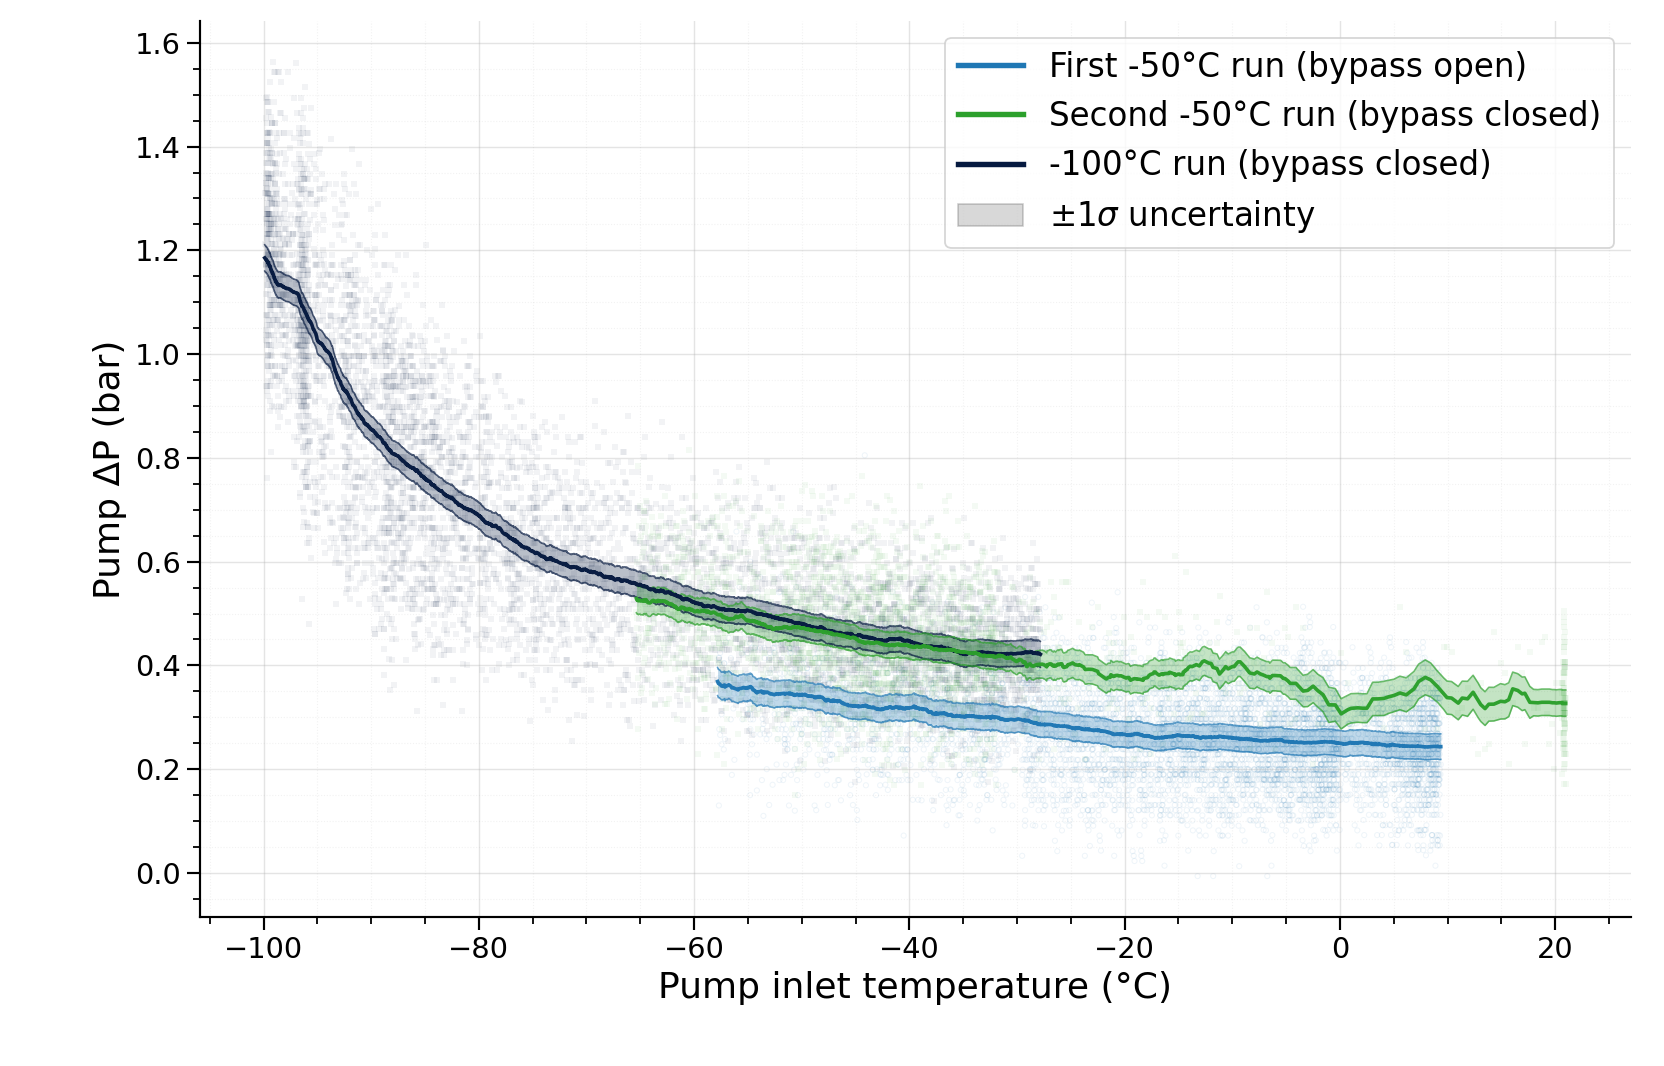

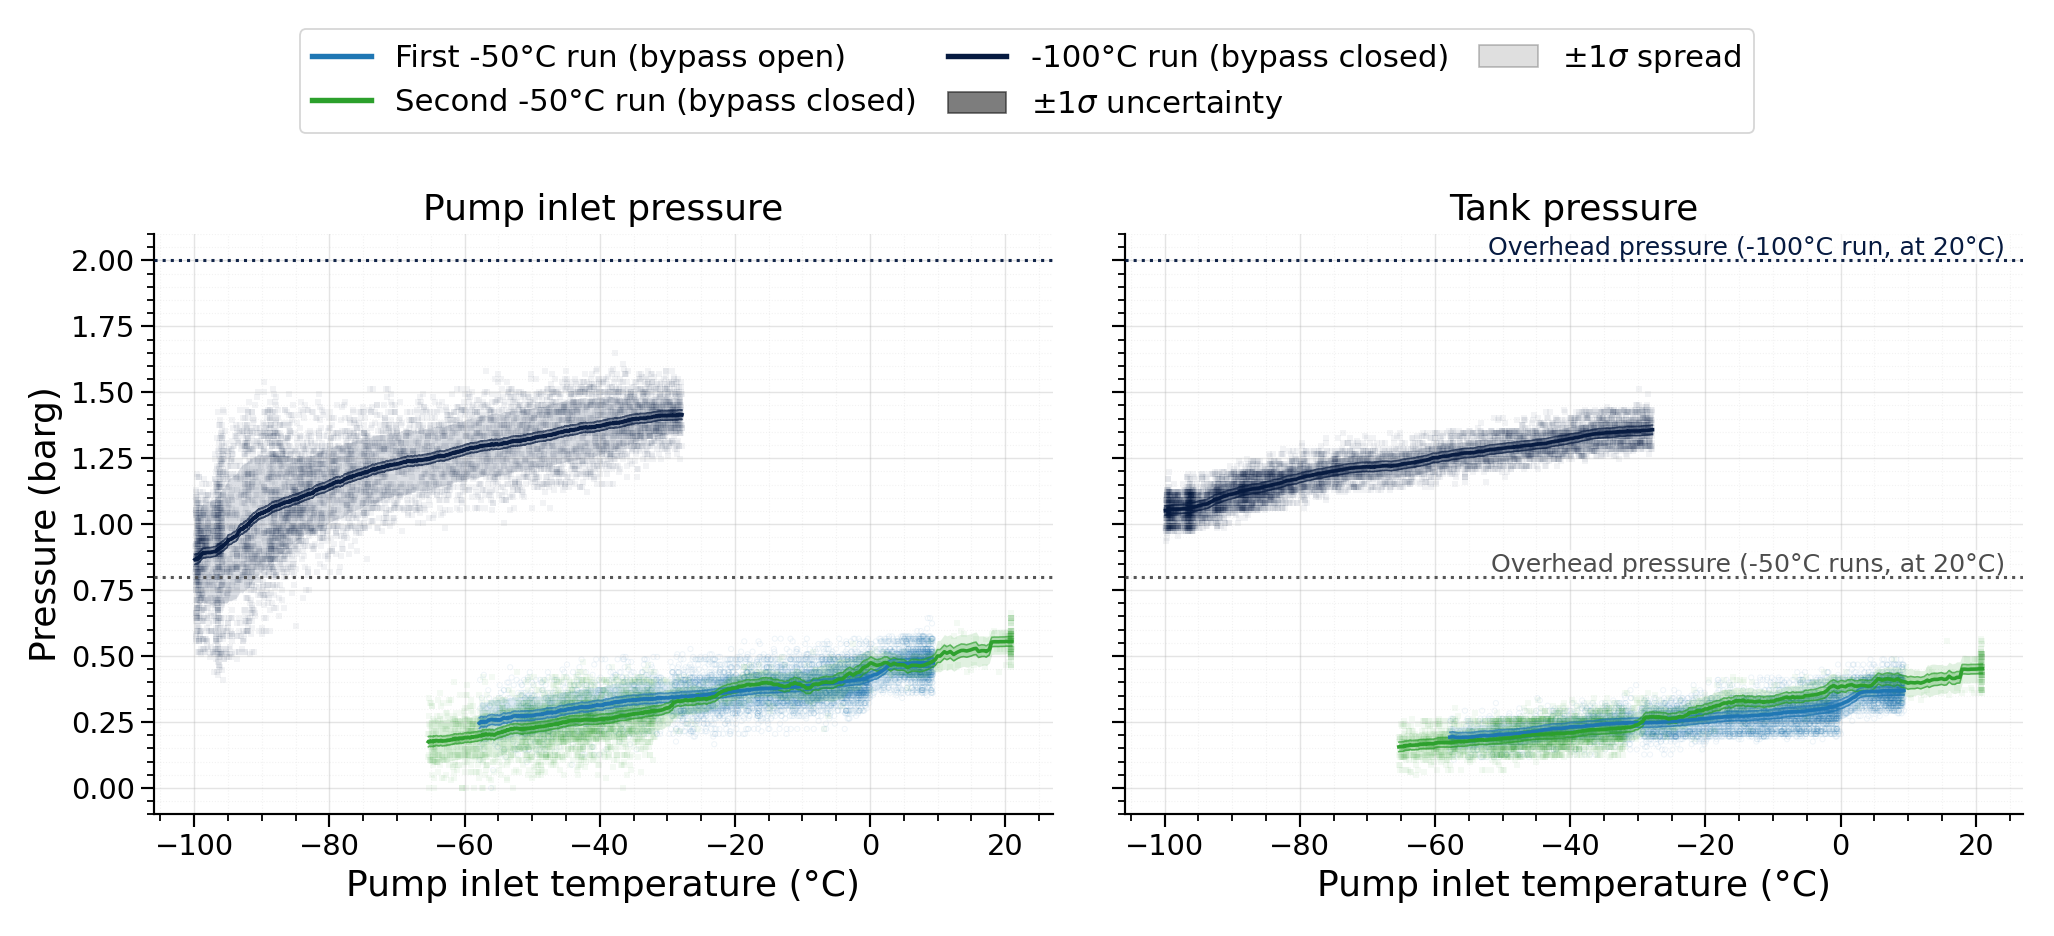

In [9]:
PRESSURE_DELTA_METRIC = ('delta_p_bar_recomputed', 'Pump ΔP (bar)')
PRESSURE_ABSOLUTE_METRICS = [
    ('pump_inlet_barg', 'Pump inlet pressure'),
    ('tank_barg', 'Tank pressure'),
]
PRESSURE_STATE_STYLES = {
    'open': {'marker': 'o', 'filled': False, 'label': 'bypass open'},
    'closed': {'marker': 's', 'filled': True, 'label': 'bypass closed'},
}
PRESSURE_ABSOLUTE_MAX_TEMPERATURE_C_BY_RUN = {}


def _pressure_metric_sensor_sigma_bar(metric):
    if metric == 'delta_p_bar_recomputed':
        return float(np.sqrt(2.0) * PRESSURE_SENSOR_SIGMA_BAR)
    return float(PRESSURE_SENSOR_SIGMA_BAR)


def _pressure_metric_readout_sigma_bar(frame, metric):
    if metric == 'delta_p_bar_recomputed':
        sigma = np.sqrt(PRESSURE_AFTER_READOUT_SIGMA_BAR ** 2 + PRESSURE_BEFORE_TANK_READOUT_SIGMA_BAR ** 2)
    else:
        sigma = PRESSURE_BEFORE_TANK_READOUT_SIGMA_BAR
    return np.full(len(frame), float(sigma))


def _window_uncertainty_components(value, readout_sigma, left, right, n):
    cumulative = np.concatenate([[0.0], np.cumsum(value)])
    cumulative_sq = np.concatenate([[0.0], np.cumsum(value * value)])

    sum_y = cumulative[right] - cumulative[left]
    sum_y2 = cumulative_sq[right] - cumulative_sq[left]

    with np.errstate(invalid='ignore', divide='ignore'):
        mean = sum_y / n
        sample_variance = (sum_y2 - (sum_y * sum_y) / n) / np.maximum(n - 1, 1)
        sample_std = np.sqrt(np.clip(sample_variance, 0.0, None))
        sem = sample_std / np.sqrt(np.maximum(n, 1))
    return mean, sem, sample_std


def _rolling_window_slope(x, y, left, right, n):
    cumulative_x = np.concatenate([[0.0], np.cumsum(x)])
    cumulative_x2 = np.concatenate([[0.0], np.cumsum(x * x)])
    cumulative_xy = np.concatenate([[0.0], np.cumsum(x * y)])
    cumulative_y = np.concatenate([[0.0], np.cumsum(y)])

    sum_x = cumulative_x[right] - cumulative_x[left]
    sum_x2 = cumulative_x2[right] - cumulative_x2[left]
    sum_xy = cumulative_xy[right] - cumulative_xy[left]
    sum_y = cumulative_y[right] - cumulative_y[left]

    with np.errstate(invalid='ignore', divide='ignore'):
        numerator = sum_xy - (sum_x * sum_y) / n
        denominator = sum_x2 - (sum_x * sum_x) / n
        slope = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator > 0.0)
    return np.where(np.isfinite(slope), slope, 0.0)


def _pressure_temperature_rolling_curve(
    subset,
    metric,
    *,
    half_width_c=PRESSURE_TEMPERATURE_ROLLING_HALF_WIDTH_C,
    min_samples=PRESSURE_TEMPERATURE_ROLLING_MIN_SAMPLES,
):
    work = subset[['temperature_for_pressure_C', metric, 'pump_pressure_error_bar']].dropna(subset=['temperature_for_pressure_C', metric]).copy()
    if work.empty:
        return pd.DataFrame(columns=['temperature_C', 'mean', 'sigma', 'n'])

    temp = work['temperature_for_pressure_C'].to_numpy(float)
    value = work[metric].to_numpy(float)
    readout_sigma = _pressure_metric_readout_sigma_bar(work, metric)
    order = np.argsort(temp)
    temp = temp[order]
    value = value[order]
    readout_sigma = readout_sigma[order]
    eval_temp = np.unique(temp)

    left = np.searchsorted(temp, eval_temp - float(half_width_c), side='left')
    right = np.searchsorted(temp, eval_temp + float(half_width_c), side='right')
    n = right - left

    mean, sem, sample_std = _window_uncertainty_components(value, readout_sigma, left, right, n)

    slope = _rolling_window_slope(temp, value, left, right, n)
    temp_sigma_c = _temperature_sigma_band(eval_temp)
    sigma_from_temperature_bar = np.abs(slope) * temp_sigma_c
    sensor_sigma_bar = _pressure_metric_sensor_sigma_bar(metric)
    total_sigma = np.sqrt(
        sensor_sigma_bar ** 2
        + sem ** 2
        + sigma_from_temperature_bar ** 2
    )

    curve = pd.DataFrame({
        'temperature_C': eval_temp,
        'mean': mean,
        'sigma': total_sigma,
        'n': n,
        'sem_component_bar': sem,
        'sample_std_bar': sample_std,
        'temperature_component_bar': sigma_from_temperature_bar,
        'sensor_component_bar': sensor_sigma_bar,
    })
    return curve[curve['n'].ge(int(min_samples))]


def _scatter_pressure_temperature_readings(ax, subset, metric, color, style):
    marker = style['marker']
    if style['filled']:
        ax.scatter(
            subset['temperature_for_pressure_C'], subset[metric],
            s=8, marker=marker, color=color, alpha=0.050, linewidths=0.0,
            zorder=1,
        )
    else:
        ax.scatter(
            subset['temperature_for_pressure_C'], subset[metric],
            s=8, marker=marker, facecolors='none', edgecolors=color,
            alpha=0.075, linewidths=0.55,
            zorder=1,
        )


def _overhead_line_groups(tolerance_bar=0.005):
    groups = []
    for key in PRESSURE_RUN_KEYS:
        y = float(ROOM_OVERHEAD_BARG_BY_RUN[key])
        for group in groups:
            if abs(group['y'] - y) <= float(tolerance_bar):
                group['keys'].append(key)
                break
        else:
            groups.append({'y': y, 'keys': [key]})
    return groups


def _overhead_group_label(keys, y):
    key_set = set(keys)
    if key_set == {'0417', '0422'}:
        return 'Overhead pressure (-50°C runs, at 20°C)'
    if key_set == {'0424'}:
        return 'Overhead pressure (-100°C run, at 20°C)'
    labels = [PRESSURE_RUN_LEGEND_LABELS.get(key, runs[key]['config']['label']).split(' (')[0] for key in keys]
    return f"Overhead pressure ({'/'.join(labels)}, at 20°C)"


def _add_overhead_lines(ax, *, annotate=False):
    xmin, xmax = ax.get_xlim()
    x_text = xmax - 0.02 * (xmax - xmin)
    for group in _overhead_line_groups():
        keys = group['keys']
        y = group['y']
        color = '0.30' if len(keys) > 1 else LOG_COLORS[keys[0]]
        ax.axhline(y, color=color, lw=1.7, linestyle=':', alpha=0.95, zorder=4.5)
        if annotate:
            ax.text(
                x_text,
                y,
                _overhead_group_label(keys, y),
                color=color,
                fontsize=DISSERTATION_ANNOTATION_FONTSIZE,
                ha='right',
                va='bottom',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.62, pad=1.8),
            )


def _plot_pressure_temperature_panel(ax, metric, ylabel=None, *, show_overhead=False, annotate_overhead=False, show_spread=False):
    for key in PRESSURE_RUN_PLOT_ORDER:
        color = LOG_COLORS[key]
        run_data = pressure_temperature_frame[pressure_temperature_frame['log_key'].eq(key)].copy()
        if metric == PRESSURE_DELTA_METRIC[0]:
            min_temp_c = PRESSURE_DELTA_MIN_TEMPERATURE_C_BY_RUN.get(key, -np.inf)
            run_data = run_data[run_data['temperature_for_pressure_C'].ge(min_temp_c)].copy()
        else:
            max_temp_c = PRESSURE_ABSOLUTE_MAX_TEMPERATURE_C_BY_RUN.get(key, np.inf)
            run_data = run_data[run_data['temperature_for_pressure_C'].le(max_temp_c)].copy()
        if run_data.empty:
            continue
        for state, style in PRESSURE_STATE_STYLES.items():
            subset = run_data[run_data['bypass_state'].eq(state)].copy()
            if subset.empty:
                continue
            _scatter_pressure_temperature_readings(ax, subset, metric, color, style)
            rolling_curve = _pressure_temperature_rolling_curve(subset, metric)
            if rolling_curve.empty:
                continue
            if show_spread:
                spread = rolling_curve['sample_std_bar'].fillna(0.0)
                ax.fill_between(
                    rolling_curve['temperature_C'],
                    rolling_curve['mean'] - spread,
                    rolling_curve['mean'] + spread,
                    color=color,
                    alpha=PRESSURE_SPREAD_BAND_ALPHA,
                    linewidth=0,
                    zorder=2.2,
                )
            lower = rolling_curve['mean'] - rolling_curve['sigma']
            upper = rolling_curve['mean'] + rolling_curve['sigma']
            ax.fill_between(
                rolling_curve['temperature_C'],
                lower,
                upper,
                color=color,
                alpha=PRESSURE_BAND_ALPHA,
                linewidth=0,
                zorder=3,
            )
            ax.plot(
                rolling_curve['temperature_C'], lower,
                color=color,
                lw=PRESSURE_BAND_EDGE_LINEWIDTH,
                alpha=PRESSURE_BAND_EDGE_ALPHA,
                zorder=3.2,
            )
            ax.plot(
                rolling_curve['temperature_C'], upper,
                color=color,
                lw=PRESSURE_BAND_EDGE_LINEWIDTH,
                alpha=PRESSURE_BAND_EDGE_ALPHA,
                zorder=3.2,
            )
            ax.plot(
                rolling_curve['temperature_C'], rolling_curve['mean'],
                color=color,
                lw=DISSERTATION_LINEWIDTH,
                alpha=0.98,
                zorder=4,
            )

    if show_overhead:
        _add_overhead_lines(ax, annotate=annotate_overhead)

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=DISSERTATION_LABEL_FONTSIZE)
    ax.tick_params(axis='both', which='major', labelsize=DISSERTATION_TICK_FONTSIZE, length=7, width=1.2)
    ax.tick_params(axis='both', which='minor', length=4, width=1.0)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    _apply_fine_grid(ax)


def _pressure_uncertainty_band_handle():
    return Patch(
        facecolor='0.45',
        edgecolor='0.30',
        linewidth=PRESSURE_BAND_EDGE_LINEWIDTH,
        alpha=PRESSURE_BAND_ALPHA,
        label=PRESSURE_UNCERTAINTY_BAND_LABEL,
    )


def _pressure_spread_band_handle():
    return Patch(
        facecolor='0.74',
        edgecolor='0.45',
        linewidth=0.9,
        alpha=0.48,
        label=PRESSURE_SPREAD_BAND_LABEL,
    )


def _pressure_temperature_legend_handles(keys=PRESSURE_RUN_KEYS, include_uncertainty=True, include_overhead=False):
    run_handles = [
        Line2D(
            [0], [0], color=LOG_COLORS[key], lw=3.0,
            label=PRESSURE_RUN_LEGEND_LABELS[key],
        )
        for key in keys
    ]
    if include_uncertainty:
        run_handles.append(_pressure_uncertainty_band_handle())
    return run_handles


PRESSURE_TWO_PANEL_FIGSIZE = (15.8, 7.2)
PRESSURE_TWO_PANEL_ADJUST = dict(left=0.075, right=0.985, top=0.75, bottom=0.13, wspace=0.08)
PRESSURE_TWO_PANEL_LEGEND_KWARGS = dict(
    loc='upper center',
    bbox_to_anchor=(0.5, 0.985),
    ncol=3,
    fontsize=DISSERTATION_LEGEND_FONTSIZE - 1,
    frameon=True,
    columnspacing=1.0,
    handlelength=1.9,
)


fig_delta, ax_delta = plt.subplots(figsize=DISSERTATION_FIGSIZE, constrained_layout=False)
_plot_pressure_temperature_panel(
    ax_delta,
    PRESSURE_DELTA_METRIC[0],
    PRESSURE_DELTA_METRIC[1],
)
ax_delta.set_xlabel('Pump inlet temperature (°C)', fontsize=DISSERTATION_LABEL_FONTSIZE)
ax_delta.legend(
    handles=_pressure_temperature_legend_handles(),
    loc='best',
    fontsize=DISSERTATION_LEGEND_FONTSIZE,
    frameon=True,
)
fig_delta.subplots_adjust(**DISSERTATION_SINGLE_ADJUST)
plt.show()

fig_abs, axes = plt.subplots(1, 2, figsize=PRESSURE_TWO_PANEL_FIGSIZE, sharex=True, sharey=True, constrained_layout=False)
for ax, (metric, panel_label), annotate in zip(axes, PRESSURE_ABSOLUTE_METRICS, [False, True]):
    _plot_pressure_temperature_panel(
        ax,
        metric,
        'Pressure (barg)' if ax is axes[0] else None,
        show_overhead=True,
        annotate_overhead=annotate,
        show_spread=True,
    )
    ax.set_title(panel_label, fontsize=DISSERTATION_TITLE_FONTSIZE, pad=8)
    ax.set_xlabel('Pump inlet temperature (°C)', fontsize=DISSERTATION_LABEL_FONTSIZE)

axes[0].set_ylim(-0.10, 2.10)
absolute_pressure_uncertainty_handle = Patch(
    facecolor='0.25',
    edgecolor='0.12',
    linewidth=PRESSURE_BAND_EDGE_LINEWIDTH,
    alpha=0.68,
    label=PRESSURE_UNCERTAINTY_BAND_LABEL,
)
fig_abs.legend(
    handles=_pressure_temperature_legend_handles(include_uncertainty=False) + [
        absolute_pressure_uncertainty_handle,
        _pressure_spread_band_handle(),
    ],
    **PRESSURE_TWO_PANEL_LEGEND_KWARGS,
)
fig_abs.subplots_adjust(**PRESSURE_TWO_PANEL_ADJUST)
plt.show()


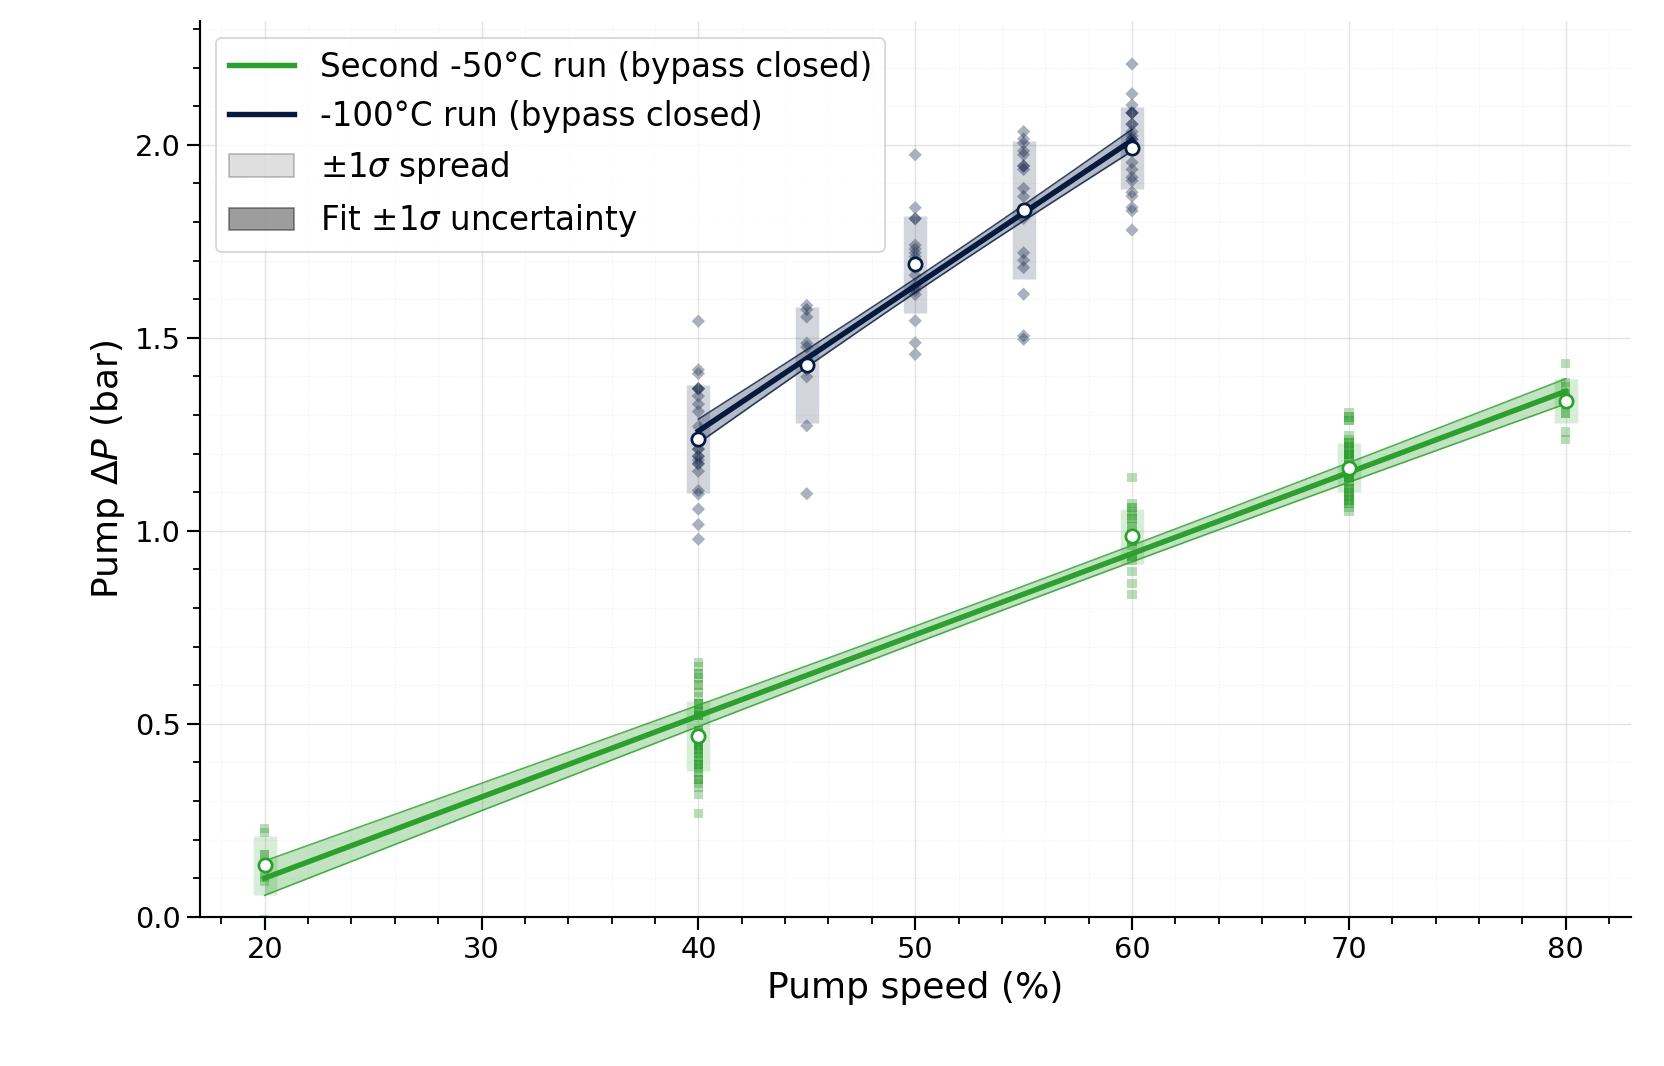

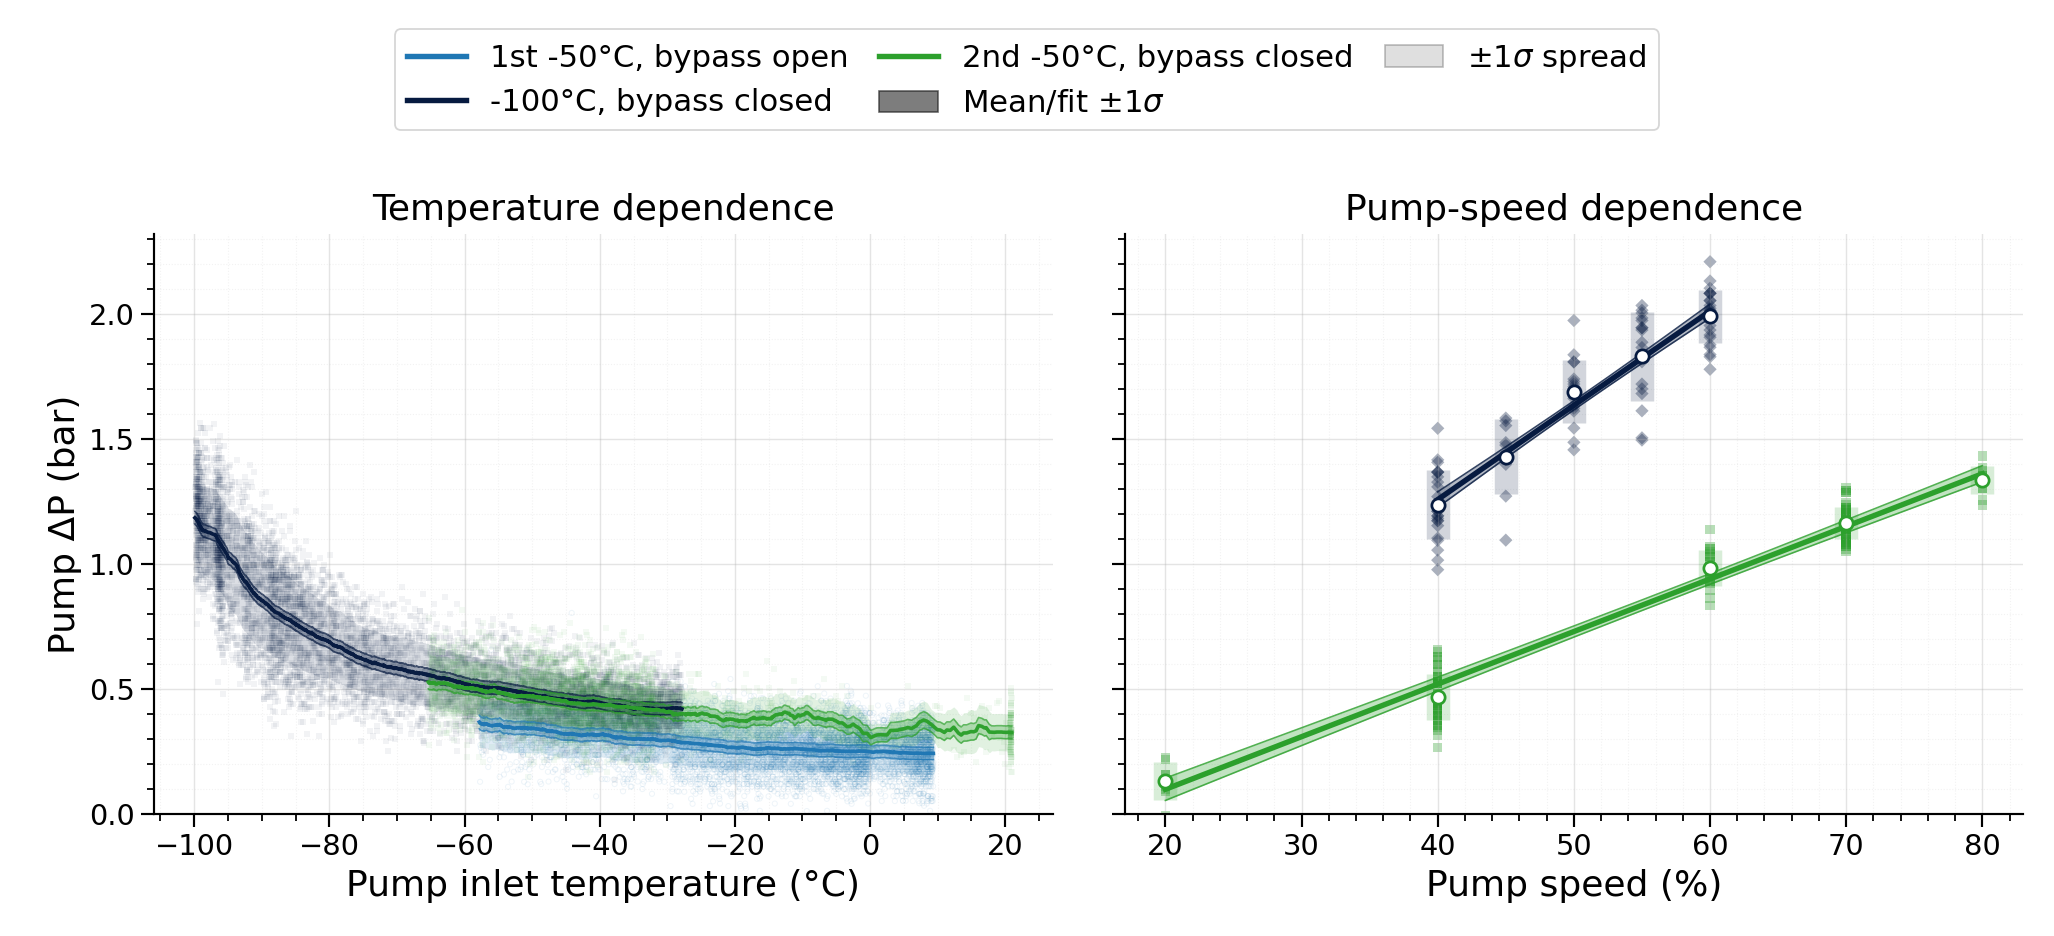

In [10]:
def _pressure_group_mean_uncertainty(group, metric):
    values = group[metric].to_numpy(float)
    n = len(values)
    readout_sigma = _pressure_metric_readout_sigma_bar(group, metric)
    mean = float(np.nanmean(values))
    sample_variance = float(np.nanvar(values, ddof=1)) if n > 1 else 0.0
    readout_var_sum = float(np.nansum(readout_sigma * readout_sigma))
    readout_sigma_mean = np.sqrt(readout_var_sum) / max(n, 1)
    mean_readout_variance = readout_var_sum / max(n, 1)
    excess_variance = max(sample_variance - mean_readout_variance, 0.0)
    excess_sem = np.sqrt(excess_variance / max(n, 1))
    sensor_sigma_bar = _pressure_metric_sensor_sigma_bar(metric)
    sigma = np.sqrt(sensor_sigma_bar ** 2 + readout_sigma_mean ** 2 + excess_sem ** 2)
    return pd.Series({
        'n': n,
        'mean': mean,
        'std': np.sqrt(sample_variance),
        'sigma': sigma,
        'excess_sem_bar': excess_sem,
        'readout_component_bar': readout_sigma_mean,
        'sensor_component_bar': sensor_sigma_bar,
        'temperature_median_C': float(group['pressure_speed_temperature_C'].median()),
        'temperature_min_C': float(group['pressure_speed_temperature_C'].min()),
        'temperature_max_C': float(group['pressure_speed_temperature_C'].max()),
        'pump_speed_pct': float(group.name),
        'pump_cmd_pct_median': float(group['pump_cmd_pct'].median()),
        'pump_cmd_pct_min': float(group['pump_cmd_pct'].min()),
        'pump_cmd_pct_max': float(group['pump_cmd_pct'].max()),
        'pump_rpm_median': float(group['pump_rotation_speed_rpm'].median()),
        'pump_rpm_min': float(group['pump_rotation_speed_rpm'].min()),
        'pump_rpm_max': float(group['pump_rotation_speed_rpm'].max()),
    })


def _pressure_speed_mean_table(subset, metric):
    table = (
        subset.groupby('cmd_round_pct')
        .apply(_pressure_group_mean_uncertainty, metric=metric, include_groups=False)
        .reset_index()
        .query('n >= @PRESSURE_SPEED_MIN_SAMPLES')
        .sort_values('pump_speed_pct')
    )
    return table


def _scatter_pressure_speed_readings(ax, subset, metric, marker, color, *, size=24, alpha=0.42):
    return ax.scatter(
        subset['pump_cmd_pct'], subset[metric],
        color=color,
        s=size,
        marker=marker,
        alpha=alpha,
        linewidths=0.0,
        edgecolors='none',
        zorder=1,
    )


def _pressure_speed_legend_label(case, subset):
    return case.get('legend', case['case'])


def _pressure_spread_band_handle():
    return Patch(
        facecolor='0.74',
        edgecolor='0.45',
        linewidth=0.9,
        alpha=0.48,
        label=PRESSURE_SPREAD_BAND_LABEL,
    )


def _pressure_speed_fit_band_handle():
    return Patch(
        facecolor='0.34',
        edgecolor='0.18',
        linewidth=0.9,
        alpha=0.58,
        label=PRESSURE_SPEED_FIT_BAND_LABEL,
    )


def _weighted_linear_fit_curve(table, *, points=220):
    fit_data = table[['pump_speed_pct', 'mean', 'sigma']].replace([np.inf, -np.inf], np.nan).dropna()
    if len(fit_data) < 2:
        return pd.DataFrame(), None

    x = fit_data['pump_speed_pct'].to_numpy(float)
    y = fit_data['mean'].to_numpy(float)
    sigma = np.clip(fit_data['sigma'].to_numpy(float), 1e-12, None)
    weights = 1.0 / (sigma * sigma)
    x0 = float(np.average(x, weights=weights))

    design = np.column_stack([np.ones_like(x), x - x0])
    xtwx = design.T @ (weights[:, None] * design)
    covariance = np.linalg.pinv(xtwx)
    beta = covariance @ (design.T @ (weights * y))

    residual = y - design @ beta
    dof = max(len(y) - 2, 0)
    chi2 = float(np.sum((residual / sigma) ** 2))
    reduced_chi2 = chi2 / dof if dof > 0 else np.nan
    covariance_scale = max(reduced_chi2, 1.0) if np.isfinite(reduced_chi2) else 1.0
    covariance = covariance * covariance_scale

    x_grid = np.linspace(float(x.min()), float(x.max()), int(points))
    pred_design = np.column_stack([np.ones_like(x_grid), x_grid - x0])
    y_fit = pred_design @ beta
    y_sigma = np.sqrt(np.sum((pred_design @ covariance) * pred_design, axis=1))

    curve = pd.DataFrame({
        'pump_speed_pct': x_grid,
        'fit': y_fit,
        'sigma': y_sigma,
    })
    stats = {
        'intercept': float(beta[0] - beta[1] * x0),
        'slope_per_percent': float(beta[1]),
        'chi2': chi2,
        'dof': dof,
        'reduced_chi2': float(reduced_chi2) if np.isfinite(reduced_chi2) else np.nan,
        'covariance_scale': float(covariance_scale),
    }
    return curve, stats


def _plot_pressure_speed_fit_with_band(ax, table, color, *, linewidth, linestyle='-', show_fit_band=True, show_spread=True):
    if table.empty:
        return None

    if show_spread:
        spread = table['std'].fillna(0.0)
        ax.vlines(
            table['pump_speed_pct'],
            table['mean'] - spread,
            table['mean'] + spread,
            color=color,
            alpha=PRESSURE_SPREAD_BAND_ALPHA * 1.28,
            linewidth=13,
            zorder=2.35,
        )

    curve, stats = _weighted_linear_fit_curve(table)
    if curve.empty:
        ax.scatter(
            table['pump_speed_pct'], table['mean'],
            s=54, facecolors='white', edgecolors=color, linewidths=1.5,
            zorder=5,
        )
        return stats

    if show_fit_band:
        lower = curve['fit'] - curve['sigma']
        upper = curve['fit'] + curve['sigma']
        ax.fill_between(
            curve['pump_speed_pct'],
            lower,
            upper,
            color=color,
            alpha=PRESSURE_BAND_ALPHA * 1.05,
            linewidth=0,
            zorder=3,
        )
        ax.plot(
            curve['pump_speed_pct'], lower,
            color=color,
            lw=PRESSURE_BAND_EDGE_LINEWIDTH,
            alpha=0.82,
            zorder=3.2,
        )
        ax.plot(
            curve['pump_speed_pct'], upper,
            color=color,
            lw=PRESSURE_BAND_EDGE_LINEWIDTH,
            alpha=0.82,
            zorder=3.2,
        )

    ax.plot(
        curve['pump_speed_pct'], curve['fit'],
        color=color,
        lw=linewidth,
        linestyle=linestyle,
        zorder=4,
    )
    ax.scatter(
        table['pump_speed_pct'], table['mean'],
        s=54, facecolors='white', edgecolors=color, linewidths=1.5,
        zorder=5,
    )
    return stats

def _format_pressure_speed_axis(ax):
    ax.tick_params(axis='both', which='major', labelsize=DISSERTATION_TICK_FONTSIZE, length=7, width=1.2)
    ax.tick_params(axis='both', which='minor', length=4, width=1.0)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    _apply_fine_grid(ax)


def _plot_pressure_speed_delta(ax_delta):
    legend_handles = []

    for case in PRESSURE_SPEED_CASE_DEFS:
        subset = pressure_speed_frame[pressure_speed_frame['speed_case'].eq(case['case'])].copy()
        if subset.empty:
            continue
        marker = case['marker']
        color = case['color']
        _scatter_pressure_speed_readings(
            ax_delta, subset, PRESSURE_DELTA_METRIC[0], marker, color,
            size=27, alpha=0.34,
        )

        delta_mean = _pressure_speed_mean_table(subset, PRESSURE_DELTA_METRIC[0])
        _plot_pressure_speed_fit_with_band(
            ax_delta,
            delta_mean,
            color,
            linewidth=DISSERTATION_FIT_LINEWIDTH,
            linestyle='-',
            show_fit_band=True,
        )
        legend_handles.append(Line2D(
            [0], [0], color=color, lw=DISSERTATION_FIT_LINEWIDTH, linestyle='-',
            label=_pressure_speed_legend_label(case, subset),
        ))

    legend_handles.append(_pressure_spread_band_handle())
    legend_handles.append(_pressure_speed_fit_band_handle())

    ax_delta.set_ylabel(r'Pump $\Delta P$ (bar)', fontsize=DISSERTATION_LABEL_FONTSIZE)
    ax_delta.set_xlabel('Pump speed (%)', fontsize=DISSERTATION_LABEL_FONTSIZE)
    ax_delta.set_ylim(bottom=0.0)
    _format_pressure_speed_axis(ax_delta)
    ax_delta.legend(
        handles=legend_handles,
        loc='upper left',
        fontsize=DISSERTATION_LEGEND_FONTSIZE,
        frameon=True,
    )
    return None


fig_speed, ax_delta_speed = plt.subplots(figsize=DISSERTATION_FIGSIZE, constrained_layout=False)
_plot_pressure_speed_delta(ax_delta_speed)
fig_speed.subplots_adjust(**DISSERTATION_SINGLE_ADJUST)
plt.show()


fig_delta_temperature_speed, axes_delta_temperature_speed = plt.subplots(
    1, 2, figsize=PRESSURE_TWO_PANEL_FIGSIZE, sharey=True, constrained_layout=False
)
_plot_pressure_temperature_panel(
    axes_delta_temperature_speed[0],
    PRESSURE_DELTA_METRIC[0],
    PRESSURE_DELTA_METRIC[1],
    show_spread=True,
)
axes_delta_temperature_speed[0].set_title('Temperature dependence', fontsize=DISSERTATION_TITLE_FONTSIZE, pad=8)
axes_delta_temperature_speed[0].set_xlabel('Pump inlet temperature (°C)', fontsize=DISSERTATION_LABEL_FONTSIZE)
_plot_pressure_speed_delta(axes_delta_temperature_speed[1])
axes_delta_temperature_speed[1].set_title('Pump-speed dependence', fontsize=DISSERTATION_TITLE_FONTSIZE, pad=8)
axes_delta_temperature_speed[1].set_ylabel('')
speed_axis_legend = axes_delta_temperature_speed[1].get_legend()
if speed_axis_legend is not None:
    speed_axis_legend.remove()

delta_ymax = max(ax.get_ylim()[1] for ax in axes_delta_temperature_speed)
for ax in axes_delta_temperature_speed:
    ax.set_ylim(0.0, delta_ymax)

combined_delta_uncertainty_handle = Patch(
    facecolor='0.25',
    edgecolor='0.12',
    linewidth=PRESSURE_BAND_EDGE_LINEWIDTH,
    alpha=0.68,
    label=r'Mean/fit $\pm 1\sigma$',
)
combined_delta_run_labels = {
    '0417': '1st -50°C, bypass open',
    '0424': '-100°C, bypass closed',
    '0422': '2nd -50°C, bypass closed',
}
combined_delta_handles = [
    Line2D(
        [0], [0], color=LOG_COLORS[key], lw=3.0,
        label=combined_delta_run_labels[key],
    )
    for key in PRESSURE_RUN_PLOT_ORDER
] + [
    combined_delta_uncertainty_handle,
    _pressure_spread_band_handle(),
]
fig_delta_temperature_speed.legend(
    handles=combined_delta_handles,
    **PRESSURE_TWO_PANEL_LEGEND_KWARGS,
)
fig_delta_temperature_speed.subplots_adjust(**PRESSURE_TWO_PANEL_ADJUST)
plt.show()


,log_key,bypass_state,run_label,samples,pump_speed_min_pct,pump_speed_max_pct,temperature_min_C,temperature_max_C,delta_p_min_bar,delta_p_max_bar
0,0422,closed,Second -50°C run (bypass closed),4054,5.0,80.0,-65.36,20.97,-0.16,1.46
1,0424,closed,-100°C run (bypass closed),6753,30.0,60.0,-99.89,-27.83,0.12,2.21


Plot 06 uses bypass-closed samples only from the Second -50°C and -100°C runs.
Point color is continuous viridis pump command; marker shape identifies the run.


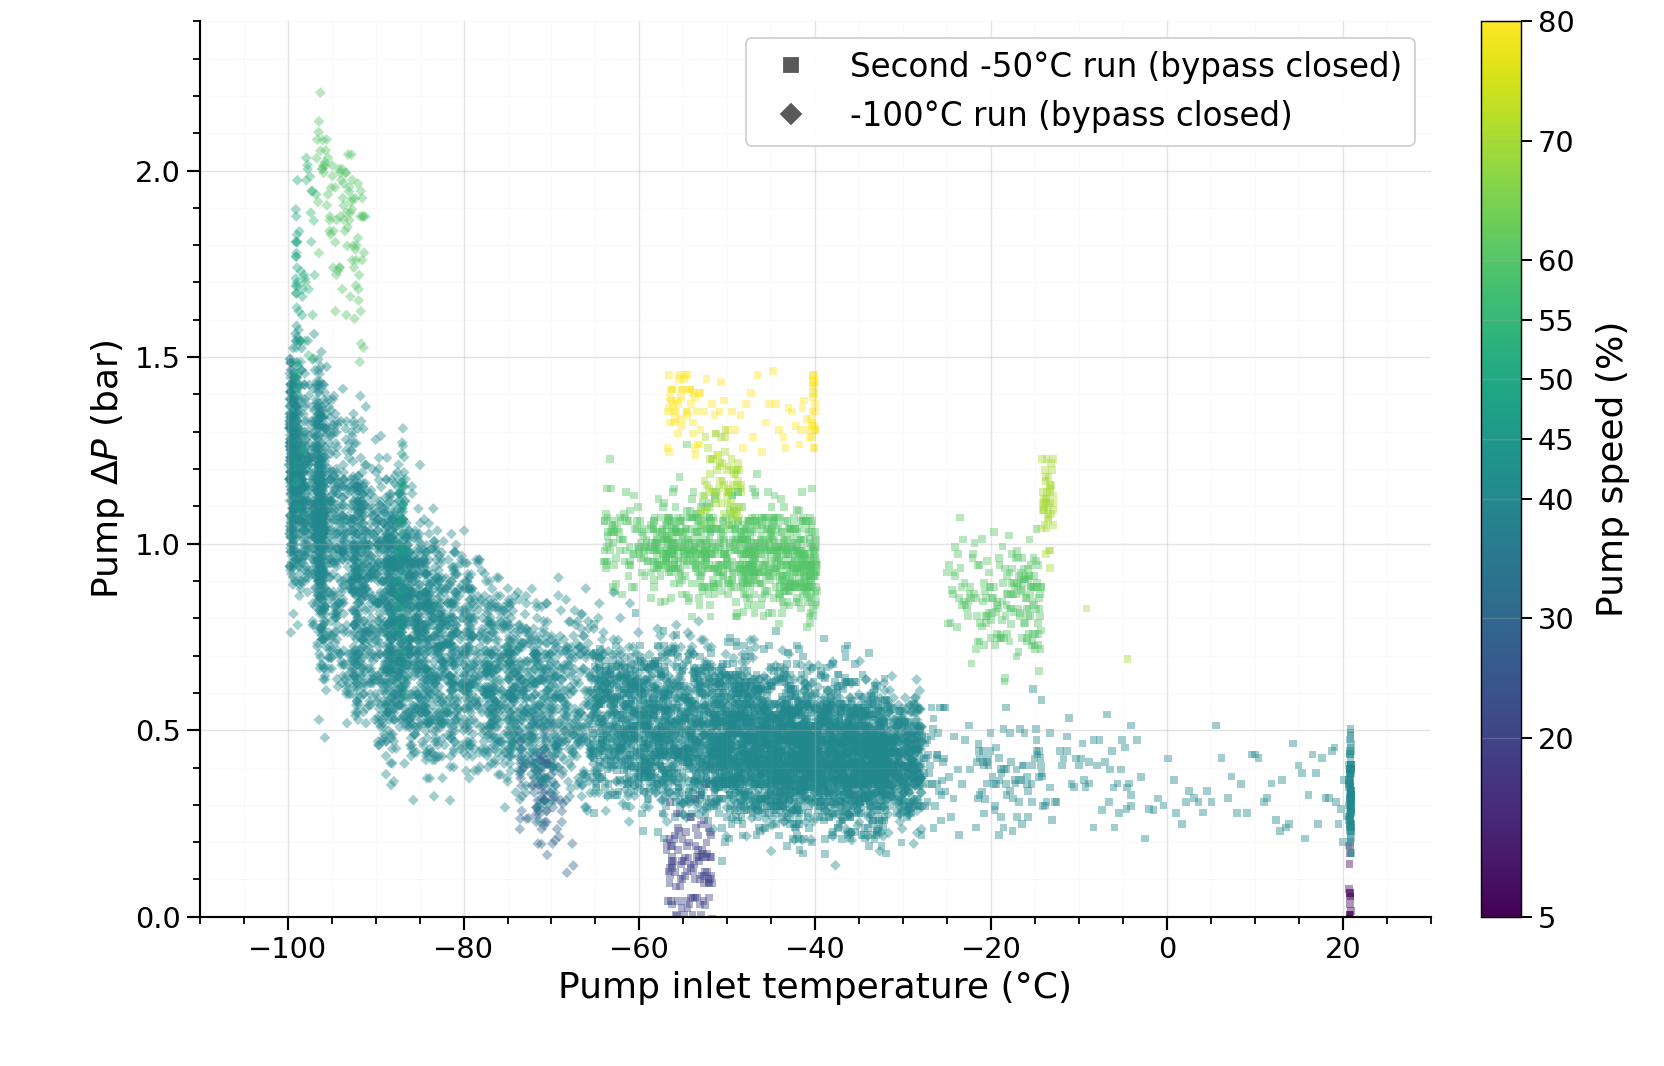

In [11]:
from matplotlib.colors import Normalize

PRESSURE_DELTA_TEMPERATURE_SPEED_KEYS = ('0422', '0424')
PRESSURE_DELTA_TEMPERATURE_SPEED_MARKERS = {
    '0422': 's',
    '0424': 'D',
}
PRESSURE_DELTA_TEMPERATURE_SPEED_LABELS = {
    '0422': 'Second -50°C run (bypass closed)',
    '0424': '-100°C run (bypass closed)',
}


def rounded_data_limits(values, *, step: float, lower_floor: float | None = None, pad_fraction: float = 0.04) -> tuple[float, float]:
    data = np.ravel(np.asarray(values, dtype=float))
    data = data[np.isfinite(data)]
    if data.size == 0:
        return (0.0 if lower_floor is None else float(lower_floor)), step
    span = max(float(data.max() - data.min()), step)
    lower = step * np.floor((float(data.min()) - pad_fraction * span) / step)
    upper = step * np.ceil((float(data.max()) + pad_fraction * span) / step)
    if lower_floor is not None:
        lower = max(float(lower_floor), float(lower))
    if lower == upper:
        upper = lower + step
    return float(lower), float(upper)


pressure_delta_temperature_speed_frame = pressure_frame[
    pressure_frame['log_key'].isin(PRESSURE_DELTA_TEMPERATURE_SPEED_KEYS)
    & pressure_frame['bypass_state'].eq('closed')
    & pressure_frame['pressure_speed_temperature_C'].notna()
    & pressure_frame['delta_p_bar_recomputed'].notna()
    & pressure_frame['pump_cmd_pct'].notna()
].copy()
pressure_delta_temperature_speed_frame['pump_cmd_pct'] = pd.to_numeric(
    pressure_delta_temperature_speed_frame['pump_cmd_pct'], errors='coerce',
)
pressure_delta_temperature_speed_frame['delta_p_bar_recomputed'] = pd.to_numeric(
    pressure_delta_temperature_speed_frame['delta_p_bar_recomputed'], errors='coerce',
)
pressure_delta_temperature_speed_frame['pressure_speed_temperature_C'] = pd.to_numeric(
    pressure_delta_temperature_speed_frame['pressure_speed_temperature_C'], errors='coerce',
)
pressure_delta_temperature_speed_frame = pressure_delta_temperature_speed_frame.dropna(
    subset=['pump_cmd_pct', 'delta_p_bar_recomputed', 'pressure_speed_temperature_C'],
)

pump_speed_levels = np.sort(pressure_delta_temperature_speed_frame['pump_cmd_pct'].dropna().unique().astype(float))
pump_speed_cmap = plt.get_cmap('viridis')
pump_speed_norm = Normalize(
    vmin=float(np.nanmin(pump_speed_levels)) if pump_speed_levels.size else 0.0,
    vmax=float(np.nanmax(pump_speed_levels)) if pump_speed_levels.size else 1.0,
)
pump_speed_mappable = plt.cm.ScalarMappable(norm=pump_speed_norm, cmap=pump_speed_cmap)
pump_speed_mappable.set_array([])

fig_delta_temp_speed, ax_delta_temp_speed = plt.subplots(figsize=DISSERTATION_FIGSIZE, constrained_layout=False)
run_handles = []
for key in PRESSURE_DELTA_TEMPERATURE_SPEED_KEYS:
    subset = pressure_delta_temperature_speed_frame[pressure_delta_temperature_speed_frame['log_key'].eq(key)].copy()
    if subset.empty:
        continue
    marker = PRESSURE_DELTA_TEMPERATURE_SPEED_MARKERS[key]
    ax_delta_temp_speed.scatter(
        subset['pressure_speed_temperature_C'],
        subset['delta_p_bar_recomputed'],
        c=subset['pump_cmd_pct'],
        cmap=pump_speed_cmap,
        norm=pump_speed_norm,
        s=18,
        marker=marker,
        alpha=0.42,
        linewidths=0.0,
        edgecolors='none',
        zorder=1,
    )
    run_handles.append(Line2D(
        [0], [0],
        marker=marker,
        linestyle='None',
        markerfacecolor='0.35',
        markeredgecolor='0.35',
        markersize=8,
        label=PRESSURE_DELTA_TEMPERATURE_SPEED_LABELS[key],
    ))

ax_delta_temp_speed.set_xlabel('Pump inlet temperature (°C)', fontsize=DISSERTATION_LABEL_FONTSIZE)
ax_delta_temp_speed.set_ylabel(r'Pump $\Delta P$ (bar)', fontsize=DISSERTATION_LABEL_FONTSIZE)
ax_delta_temp_speed.set_xlim(*rounded_data_limits(pressure_delta_temperature_speed_frame['pressure_speed_temperature_C'], step=10.0))
ax_delta_temp_speed.set_ylim(*rounded_data_limits(pressure_delta_temperature_speed_frame['delta_p_bar_recomputed'], step=0.1, lower_floor=0.0))
ax_delta_temp_speed.tick_params(axis='both', which='major', labelsize=DISSERTATION_TICK_FONTSIZE, length=7, width=1.2)
ax_delta_temp_speed.tick_params(axis='both', which='minor', length=4, width=1.0)
for spine in ax_delta_temp_speed.spines.values():
    spine.set_linewidth(1.2)
_apply_fine_grid(ax_delta_temp_speed)
if run_handles:
    legend = ax_delta_temp_speed.legend(handles=run_handles, loc='best', fontsize=DISSERTATION_LEGEND_FONTSIZE, frameon=True)
    legend.get_frame().set_alpha(0.92)

fig_delta_temp_speed.subplots_adjust(**DISSERTATION_COLORBAR_ADJUST)
cax = fig_delta_temp_speed.add_axes([0.89, 0.14, 0.024, 0.84])
cbar = fig_delta_temp_speed.colorbar(
    pump_speed_mappable,
    cax=cax,
    orientation='vertical',
    ticks=pump_speed_levels,
)
cbar.set_label('Pump speed (%)', fontsize=DISSERTATION_LABEL_FONTSIZE, labelpad=12)
cbar.ax.tick_params(labelsize=DISSERTATION_TICK_FONTSIZE, length=6, width=1.1)
cbar.ax.set_yticklabels([f'{level:g}' for level in pump_speed_levels])

pressure_delta_temperature_speed_diagnostic = (
    pressure_delta_temperature_speed_frame
    .groupby(['log_key', 'bypass_state'], observed=True)
    .agg(
        run_label=('log_key', lambda keys: PRESSURE_DELTA_TEMPERATURE_SPEED_LABELS[str(keys.iloc[0])]),
        samples=('delta_p_bar_recomputed', 'size'),
        pump_speed_min_pct=('pump_cmd_pct', 'min'),
        pump_speed_max_pct=('pump_cmd_pct', 'max'),
        temperature_min_C=('pressure_speed_temperature_C', 'min'),
        temperature_max_C=('pressure_speed_temperature_C', 'max'),
        delta_p_min_bar=('delta_p_bar_recomputed', 'min'),
        delta_p_max_bar=('delta_p_bar_recomputed', 'max'),
    )
    .reset_index()
)
display(pressure_delta_temperature_speed_diagnostic.round(2))
print('Plot 06 uses bypass-closed samples only from the Second -50°C and -100°C runs.')
print('Point color is continuous viridis pump command; marker shape identifies the run.')
plt.show()


In [12]:
apr22 = pressure_frame[pressure_frame['log_key'].eq('0422')].copy()
apr22_high = apr22[pd.to_numeric(apr22['pump_cmd_pct'], errors='coerce').ge(60.0)].copy()
apr22_pumping = apr22.copy()

apr24 = pressure_frame[pressure_frame['log_key'].eq('0424')].copy()
apr24_closed_40 = apr24[pd.to_numeric(apr24['pump_cmd_pct'], errors='coerce').round().eq(40.0)].copy()

head_bar_per_m_warm = 1450.0 * 9.80665 / 1e5
head_bar_per_m_cold = 1700.0 * 9.80665 / 1e5

summary_text = (
    f"Open-bypass samples from April 22 and April 24 are excluded from the pressure plots and pressure summaries. "
    f"The April 17 data are kept as bypass open, while April 22 and April 24 are kept only as bypass closed.\n\n"
    f"The April 17 and April 22 overhead references overlap at `{ROOM_OVERHEAD_BARG_BY_RUN['0422']:.3f} barg`; the plot therefore shows them as one combined April 17/22 line. "
    f"The April 17 value starts from the April 22 specified `{ROOM_OVERHEAD_BARG_0422:.1f} barg` room overhead and applies the "
    f"room-temperature tank-channel offset "
    f"`{apr17_minus_apr22_room_tank_bar:+.3f} bar` measured between the included April 17 and April 22 room-temperature pressure data. "
    f"The April 24 overhead line is the specified `{ROOM_OVERHEAD_BARG_BY_RUN['0424']:.1f} barg`.\n\n"
    f"April 22 high-speed bypass-closed samples (pump speed >= 60%) have pump-inlet pressure min "
    f"`{apr22_high['pump_inlet_barg'].min():.3f} barg` "
    f"(`{apr22_high['pump_pressure_before_bar_abs'].min():.3f} bar abs`) and median "
    f"`{apr22_high['pump_inlet_barg'].median():.3f} barg`. "
    f"The tank/gas-trap channel over included April 22 pumping has median "
    f"`{apr22_pumping['tank_barg'].median():.3f} barg`, "
    f"with high-speed median `{apr22_high['tank_barg'].median():.3f} barg`.\n\n"
    f"For April 24 bypass-closed 40% pump-speed samples, the tank-pressure median is "
    f"`{apr24_closed_40['tank_barg'].median():.3f} barg`. "
    f"The specified 2-barg overhead line is therefore above most of the cold bypass-closed tank-pressure data.\n\n"
    f"Hydrostatic head can make a liquid-side tank tap slightly higher than the gas-space overhead, "
    f"but the scale is small: roughly `{head_bar_per_m_warm:.3f}` to `{head_bar_per_m_cold:.3f} bar per meter` "
    f"of HFE liquid head."
)

display(Markdown(summary_text))


Open-bypass samples from April 22 and April 24 are excluded from the pressure plots and pressure summaries. The April 17 data are kept as bypass open, while April 22 and April 24 are kept only as bypass closed.

The April 17 and April 22 overhead references overlap at `0.800 barg`; the plot therefore shows them as one combined April 17/22 line. The April 17 value starts from the April 22 specified `0.8 barg` room overhead and applies the room-temperature tank-channel offset `+0.000 bar` measured between the included April 17 and April 22 room-temperature pressure data. The April 24 overhead line is the specified `2.0 barg`.

April 22 high-speed bypass-closed samples (pump speed >= 60%) have pump-inlet pressure min `-0.000 barg` (`1.013 bar abs`) and median `-0.000 barg`. The tank/gas-trap channel over included April 22 pumping has median `0.185 barg`, with high-speed median `0.098 barg`.

For April 24 bypass-closed 40% pump-speed samples, the tank-pressure median is `1.190 barg`. The specified 2-barg overhead line is therefore above most of the cold bypass-closed tank-pressure data.

Hydrostatic head can make a liquid-side tank tap slightly higher than the gas-space overhead, but the scale is small: roughly `0.142` to `0.167 bar per meter` of HFE liquid head.

In [13]:
import zipfile

PLOT_EXPORT_DIR = REPO_ROOT / 'analysis' / 'notebooks' / 'system_performance_plots'
PLOT_EXPORT_ZIP = REPO_ROOT / 'analysis' / 'notebooks' / 'system_performance_plots.zip'
PLOT_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

plot_exports = [
    (fig_warmup, '01_warmup_heat_leaks.png'),
    (fig_cooling, '02_cooling_performance.png'),
    (fig_delta, '03_pump_delta_p_vs_temperature.png'),
    (fig_abs, '04_pump_inlet_and_tank_pressure_vs_temperature.png'),
    (fig_speed, '05_pump_delta_p_vs_pump_speed.png'),
    (fig_delta_temp_speed, '06_pump_delta_p_vs_temperature_vs_pump_speed.png'),
    (fig_delta_temperature_speed, '07_pump_delta_p_temperature_and_speed.png'),
]

for figure, filename in plot_exports:
    figure.savefig(PLOT_EXPORT_DIR / filename, dpi=300, bbox_inches='tight')

readme_text = '\n'.join([
    'System performance plots exported from analysis/notebooks/system_performance.ipynb',
    '',
    *[filename for _, filename in plot_exports],
]) + '\n'
(PLOT_EXPORT_DIR / 'README.txt').write_text(readme_text)

with zipfile.ZipFile(PLOT_EXPORT_ZIP, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    archive.writestr('system_performance_plots/', '')
    for path in sorted(PLOT_EXPORT_DIR.iterdir()):
        if path.is_file():
            archive.write(path, arcname=f'system_performance_plots/{path.name}')

display(Markdown(f'Exported `{len(plot_exports)}` plots to `{PLOT_EXPORT_DIR}` and rebuilt `{PLOT_EXPORT_ZIP.name}`.'))


Exported `7` plots to `/home/aamy/Documents/hfe-system/analysis/notebooks/system_performance_plots` and rebuilt `system_performance_plots.zip`.